In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configurar estilo - versão compatível
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Definir paleta de cores manualmente
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

In [36]:
# Carregar os datasets com dados de todas as propriedades
df_degradation = pd.read_csv("all_properties_degradation_results.csv")
df_explanation = pd.read_csv("all_properties_explanation_results.csv")

print("=== ESTRUTURA DOS NOVOS DATASETS ===")
print(f"Degradation dataset: {df_degradation.shape}")
print(f"Explanation dataset: {df_explanation.shape}")
print(f"\nPropriedades únicas: {df_degradation['property'].nunique()}")
print(f"Lista de propriedades:")
for prop in df_degradation['property'].unique():
    print(f"  - {prop}")

=== ESTRUTURA DOS NOVOS DATASETS ===
Degradation dataset: (504, 8)
Explanation dataset: (504, 10)

Propriedades únicas: 14
Lista de propriedades:
  - Rotational constant A: GHz
  - Rotational constant B: GHz
  - Rotational constant C: GHz
  - Dipole moment (μ): Debye (D)
  - Isotropic polarizability (α): atomic units (a.u.)
  - Energy of HOMO (ϵHOMO): Hartree (Ha)
  - Energy of LUMO (ϵLUMO): Hartree (Ha)
  - Gap (ϵgap): Hartree (Ha)
  - Electronic spatial extent: atomic units (a.u.)
  - Zero point vibrational energy (zpve): Hartree (Ha)
  - Internal energy at 0 K (U0): Hartree (Ha)
  - Internal energy at 298.15 K (U): Hartree (Ha)
  - Enthalpy at 298.15 K (H): Hartree (Ha)
  - Free energy at 298.15 K (G): Hartree (Ha)


In [37]:
# Visualizar estrutura dos dados
print("=== DEGRADATION DATASET ===")
print(df_degradation.head())
print(f"\nColunas: {df_degradation.columns.tolist()}")
print(f"\nInfo por propriedade:")
print(df_degradation.groupby('property').agg({
    'iteration': ['count', 'max'],
    'n_features': ['min', 'max'],
    'test_loss': ['min', 'max', 'mean']
}).round(4))

=== DEGRADATION DATASET ===
                     property  property_idx  iteration  n_features  \
0  Rotational constant A: GHz             0          1        1057   
1  Rotational constant A: GHz             0          2         951   
2  Rotational constant A: GHz             0          3         855   
3  Rotational constant A: GHz             0          4         769   
4  Rotational constant A: GHz             0          5         692   

   train_loss      val_loss  test_loss  n_epochs  
0    0.004391  5.300000e-07   0.000001        13  
1    0.004392  6.500000e-07   0.000001        15  
2    0.004391  5.600000e-07   0.000001        13  
3    0.004391  5.500000e-07   0.000001        18  
4    0.004392  7.100000e-07   0.000001        19  

Colunas: ['property', 'property_idx', 'iteration', 'n_features', 'train_loss', 'val_loss', 'test_loss', 'n_epochs']

Info por propriedade:
                                                   iteration     n_features  \
                          

In [38]:
# Visualizar estrutura dos dados de explicação
print("=== EXPLANATION DATASET ===")
print(df_explanation.head())
print(f"\nColunas: {df_explanation.columns.tolist()}")
print(f"\nInfo por propriedade:")
print(df_explanation.groupby('property').agg({
    'iteration': ['count', 'max'],
    'n_features': ['min', 'max']
}).round(4))

=== EXPLANATION DATASET ===
                     property  property_idx  iteration  n_features  \
0  Rotational constant A: GHz             0          1         951   
1  Rotational constant A: GHz             0          2         855   
2  Rotational constant A: GHz             0          3         769   
3  Rotational constant A: GHz             0          4         692   
4  Rotational constant A: GHz             0          5         622   

                                   features_selected  \
0  ['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...   
1  ['nAcid', 'ATS0dv', 'ATS1dv', 'ATS2dv', 'ATS3d...   
2  ['nAcid', 'ATS4m', 'ATS1are', 'ATS2are', 'ATS3...   
3  ['nAcid', 'AATS1d', 'AATS2d', 'AATS0Z', 'AATS1...   
4  ['nAcid', 'ATSC0Z', 'ATSC1Z', 'ATSC2Z', 'ATSC3...   

                                    original_indices  test_loss  \
0  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   0.000001   
1  [0, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42...   0.000001   
2  [0, 63, 96

In [39]:
df_degradation.info()
df_explanation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   property      504 non-null    object 
 1   property_idx  504 non-null    int64  
 2   iteration     504 non-null    int64  
 3   n_features    504 non-null    int64  
 4   train_loss    504 non-null    float64
 5   val_loss      504 non-null    float64
 6   test_loss     504 non-null    float64
 7   n_epochs      504 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 31.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   property           504 non-null    object 
 1   property_idx       504 non-null    int64  
 2   iteration          504 non-null    int64  
 3   n_features         504 non-null    int64  
 4   featu

In [40]:
# Primeiro, vamos verificar as colunas disponíveis
print("Colunas em df_explanation:")
print(df_explanation.columns.tolist())
print("\nPrimeiras linhas:")
print(df_explanation.head())

print("\nColunas em df_degradation:")
print(df_degradation.columns.tolist())
print("\nPrimeiras linhas:")
print(df_degradation.head())

Colunas em df_explanation:
['property', 'property_idx', 'iteration', 'n_features', 'features_selected', 'original_indices', 'test_loss', 'shap_explanation', 'positive_fidelity', 'negative_fidelity']

Primeiras linhas:
                     property  property_idx  iteration  n_features  \
0  Rotational constant A: GHz             0          1         951   
1  Rotational constant A: GHz             0          2         855   
2  Rotational constant A: GHz             0          3         769   
3  Rotational constant A: GHz             0          4         692   
4  Rotational constant A: GHz             0          5         622   

                                   features_selected  \
0  ['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...   
1  ['nAcid', 'ATS0dv', 'ATS1dv', 'ATS2dv', 'ATS3d...   
2  ['nAcid', 'ATS4m', 'ATS1are', 'ATS2are', 'ATS3...   
3  ['nAcid', 'AATS1d', 'AATS2d', 'AATS0Z', 'AATS1...   
4  ['nAcid', 'ATSC0Z', 'ATSC1Z', 'ATSC2Z', 'ATSC3...   

                        

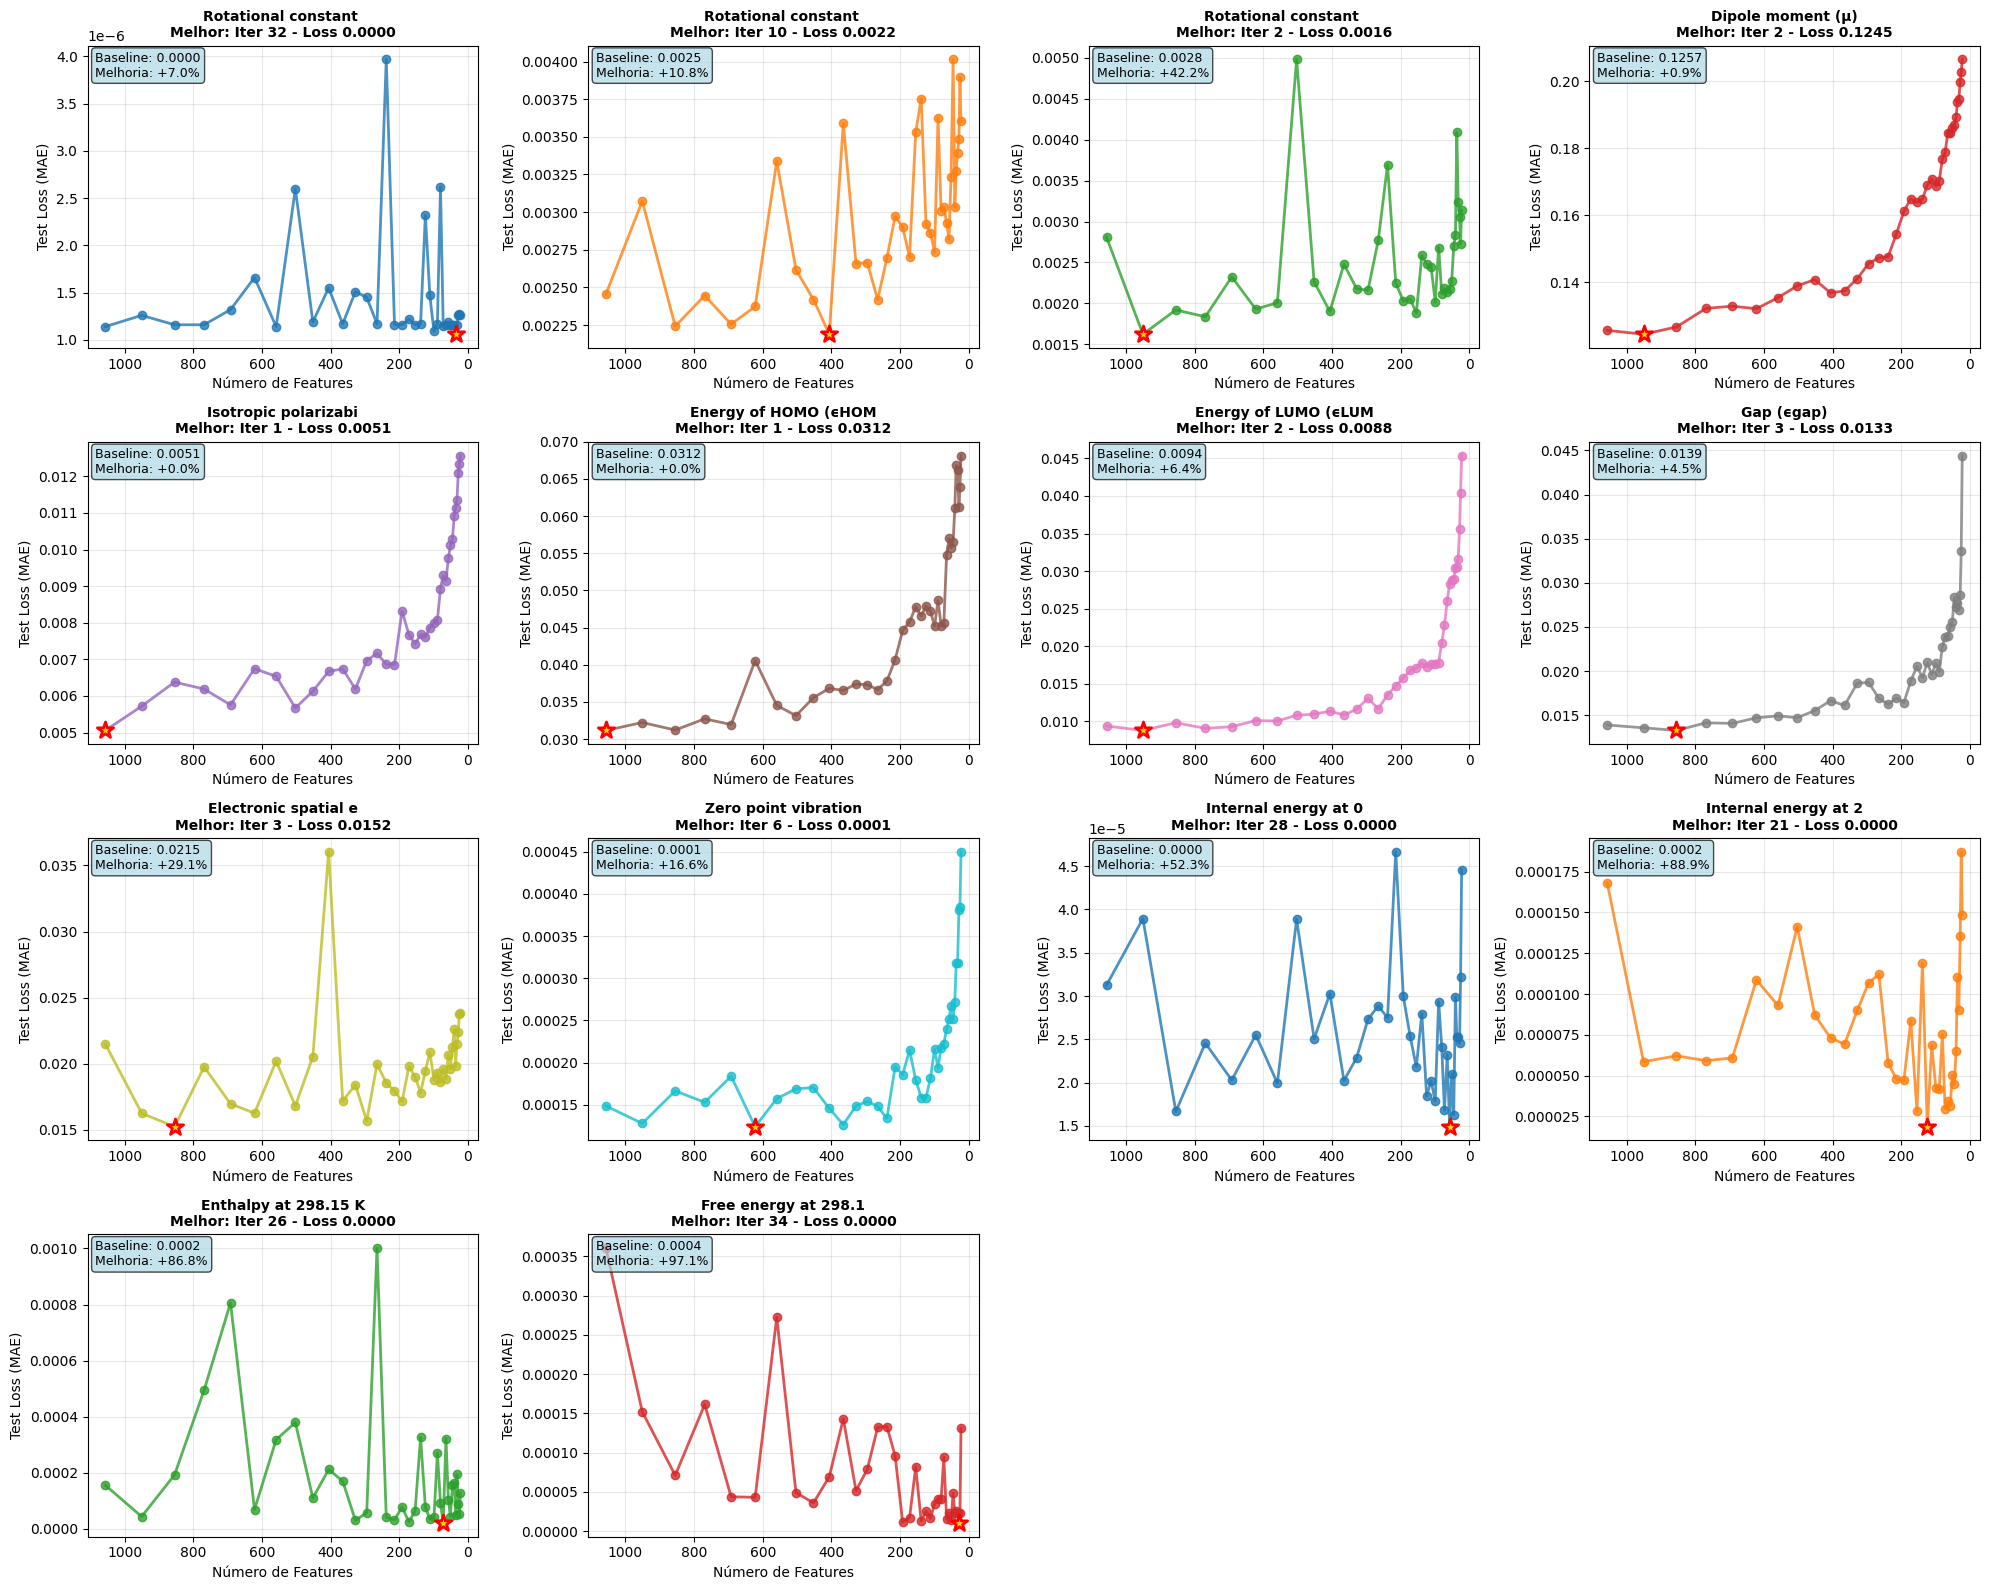

In [41]:
# 1. ANÁLISE INDIVIDUAL DE PERFORMANCE PARA CADA PROPRIEDADE
properties = df_degradation['property'].unique()
n_props = len(properties)

# Calcular layout de subplots (aproximadamente quadrado)
n_cols = int(np.ceil(np.sqrt(n_props)))
n_rows = int(np.ceil(n_props / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_props > 1 else [axes]

for i, prop in enumerate(properties):
    prop_data = df_degradation[df_degradation['property'] == prop]
    
    # Plot da evolução da performance vs features
    axes[i].plot(prop_data['n_features'], prop_data['test_loss'], 
                'o-', label='Test Loss', linewidth=2, markersize=6, 
                color=colors[i % len(colors)], alpha=0.8)
    
    # Destacar melhor ponto
    best_idx = prop_data['test_loss'].idxmin()
    best_n_feat = prop_data.loc[best_idx, 'n_features']
    best_loss = prop_data.loc[best_idx, 'test_loss']
    best_iter = prop_data.loc[best_idx, 'iteration']
    
    axes[i].scatter(best_n_feat, best_loss, s=150, color='gold', 
                   edgecolor='red', linewidth=2, zorder=5, marker='*')
    
    # Configurações do gráfico
    axes[i].set_xlabel('Número de Features')
    axes[i].set_ylabel('Test Loss (MAE)')
    axes[i].set_title(f'{prop.split(":")[0][:20]}\nMelhor: Iter {int(best_iter)} - Loss {best_loss:.4f}', 
                     fontsize=10, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].invert_xaxis()
    
    # Adicionar informações estatísticas
    baseline_loss = prop_data['test_loss'].iloc[0]
    improvement = ((baseline_loss - best_loss) / baseline_loss) * 100
    
    axes[i].text(0.02, 0.98, 
                f'Baseline: {baseline_loss:.4f}\nMelhoria: {improvement:+.1f}%', 
                transform=axes[i].transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))

# Esconder subplots não utilizados
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

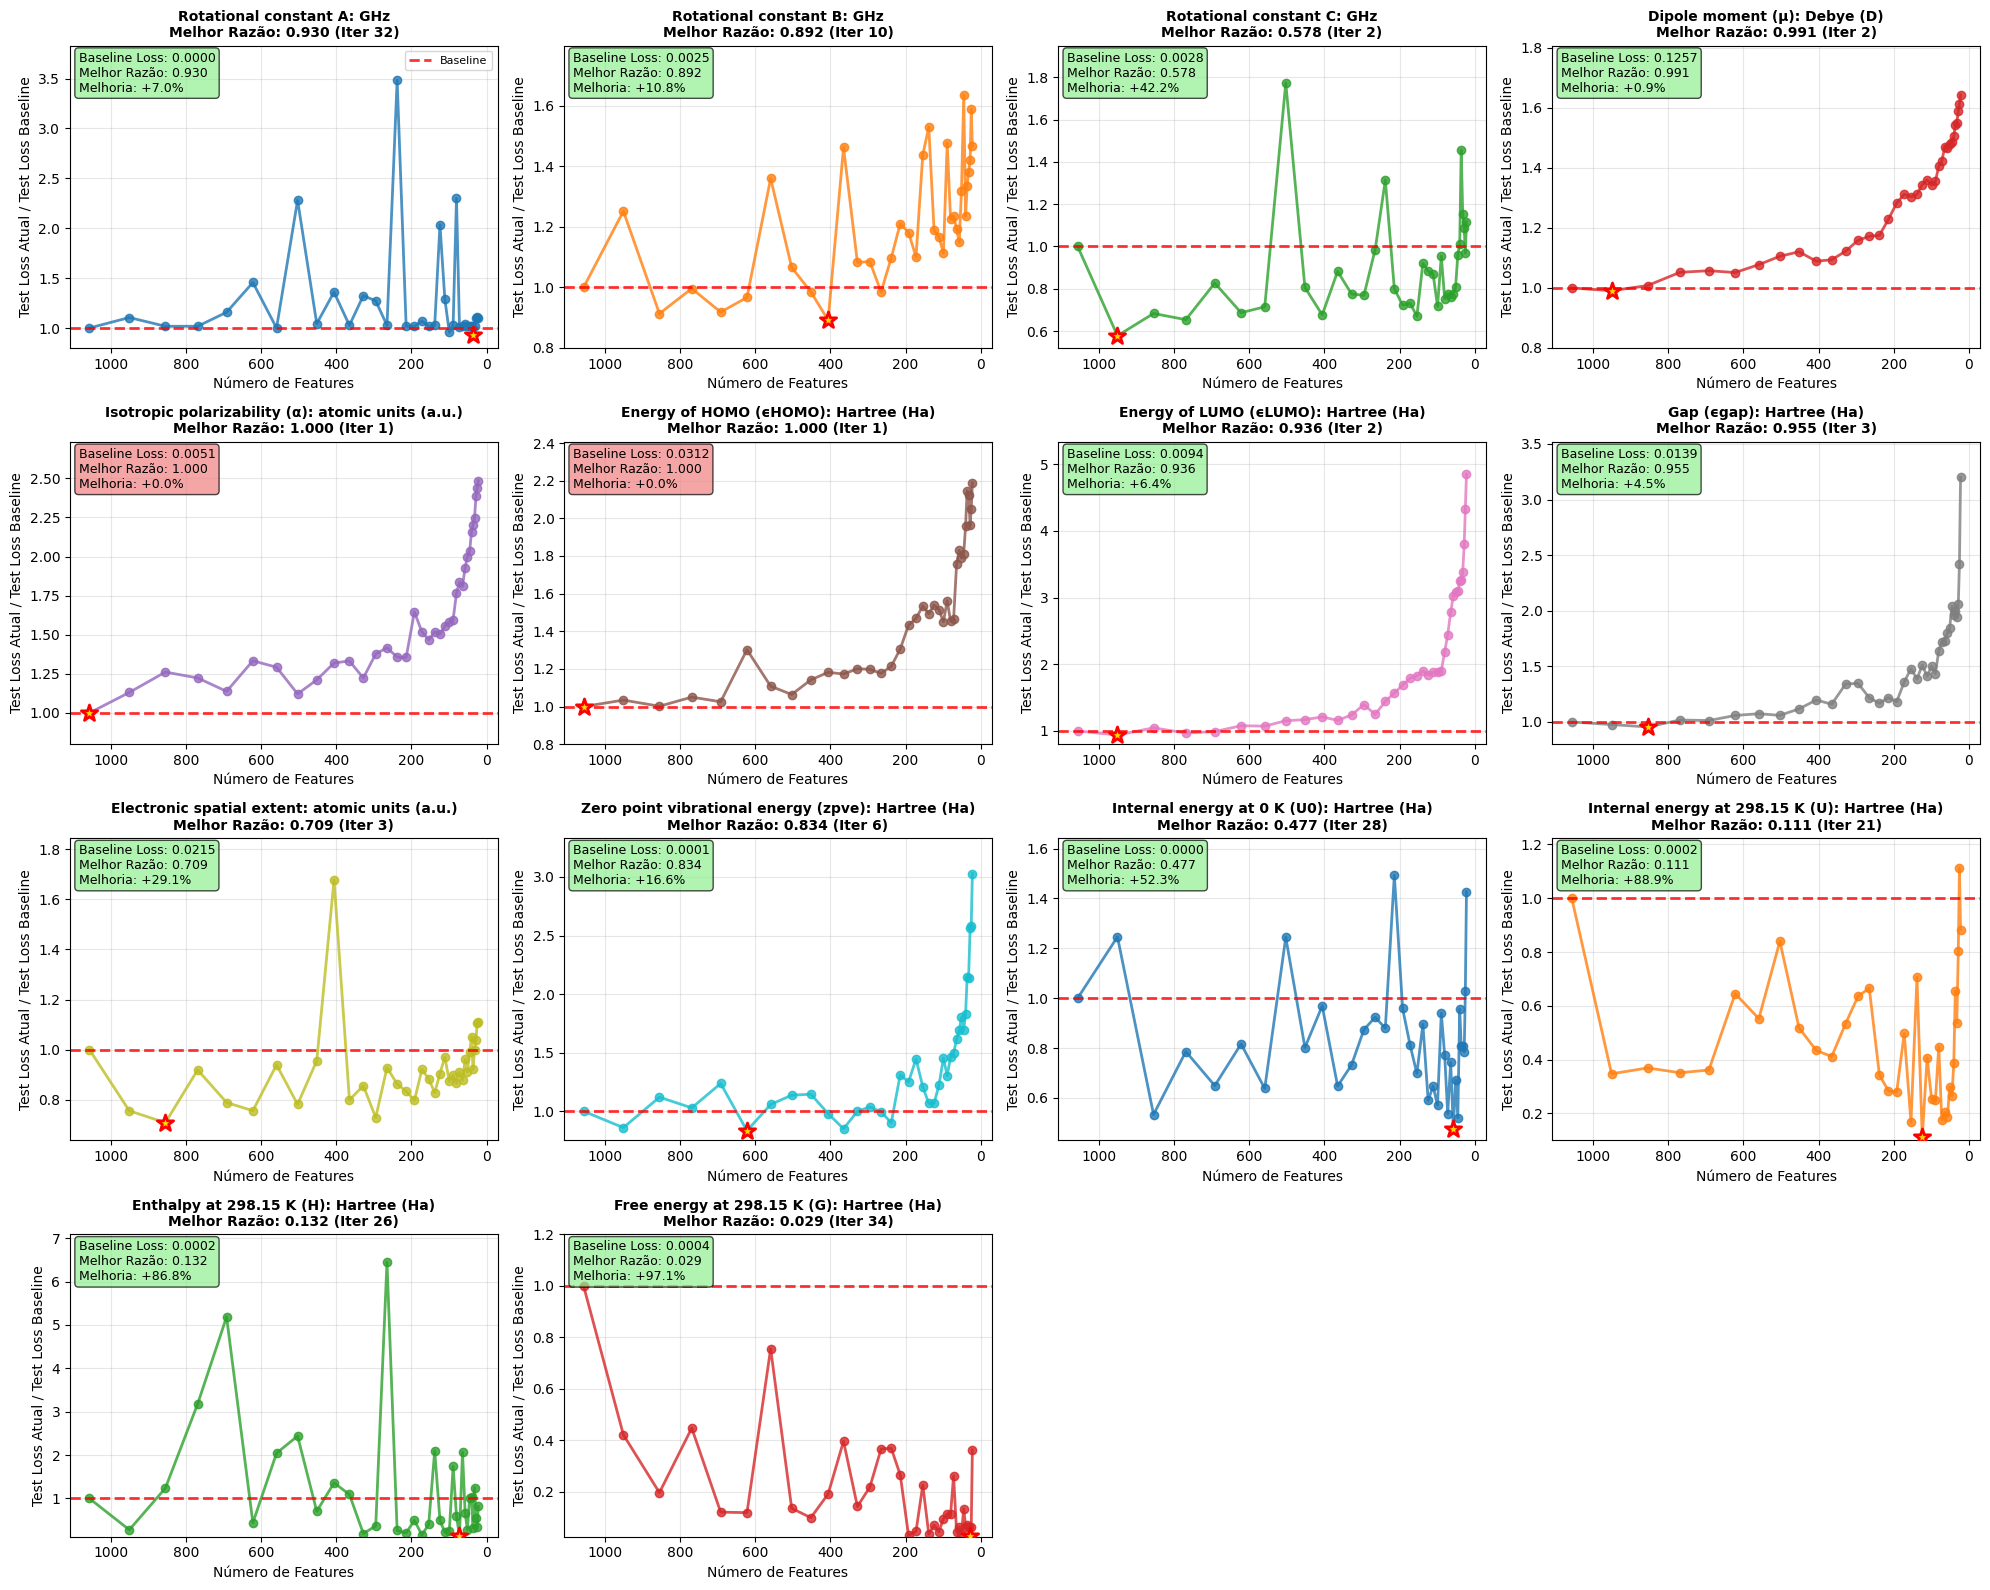

In [42]:
# 1.5. ANÁLISE DE PERFORMANCE RELATIVA (Test Loss Atual / Test Loss Baseline)
properties = df_degradation['property'].unique()
n_props = len(properties)

# Calcular layout de subplots (aproximadamente quadrado)
n_cols = int(np.ceil(np.sqrt(n_props)))
n_rows = int(np.ceil(n_props / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_props > 1 else [axes]

for i, prop in enumerate(properties):
    prop_data = df_degradation[df_degradation['property'] == prop]
    
    # Calcular test loss baseline (primeira iteração com 1057 features)
    baseline_loss = prop_data['test_loss'].iloc[0]
    
    # Calcular razão: test_loss_atual / test_loss_baseline
    loss_ratio = prop_data['test_loss'] / baseline_loss
    
    # Plot da evolução da razão vs número de features
    axes[i].plot(prop_data['n_features'], loss_ratio, 
                'o-', linewidth=2, markersize=6, 
                color=colors[i % len(colors)], alpha=0.8)
    
    # Destacar melhor ponto (menor razão)
    best_idx = loss_ratio.idxmin()
    best_n_feat = prop_data.loc[best_idx, 'n_features']
    best_ratio = loss_ratio.iloc[prop_data.index.get_loc(best_idx)]
    best_iter = prop_data.loc[best_idx, 'iteration']
    
    axes[i].scatter(best_n_feat, best_ratio, s=150, color='gold', 
                   edgecolor='red', linewidth=2, zorder=5, marker='*')
    
    # Linha de referência (sem melhoria/piora)
    axes[i].axhline(y=1.0, color='red', linestyle='--', alpha=0.8, linewidth=2, label='Baseline')
    
    # Configurações do gráfico
    axes[i].set_xlabel('Número de Features')
    axes[i].set_ylabel('Test Loss Atual / Test Loss Baseline')
    # Usar o nome completo da propriedade no título
    axes[i].set_title(f"{prop}\nMelhor Razão: {best_ratio:.3f} (Iter {int(best_iter)})", 
                     fontsize=10, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].invert_xaxis()
    
    # Definir limite do eixo Y para melhor visualização
    y_max = max(1.2, loss_ratio.max() * 1.1)
    y_min = min(0.8, loss_ratio.min() * 0.9)
    axes[i].set_ylim(y_min, y_max)
    
    # Adicionar informações estatísticas
    improvement_pct = (1 - best_ratio) * 100
    
    axes[i].text(0.02, 0.98, 
                f'Baseline Loss: {baseline_loss:.4f}\nMelhor Razão: {best_ratio:.3f}\nMelhoria: {improvement_pct:+.1f}%', 
                transform=axes[i].transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen' if best_ratio < 1 else 'lightcoral', alpha=0.7))

# Esconder subplots não utilizados
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Adicionar legenda geral
if n_props > 0:
    axes[0].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

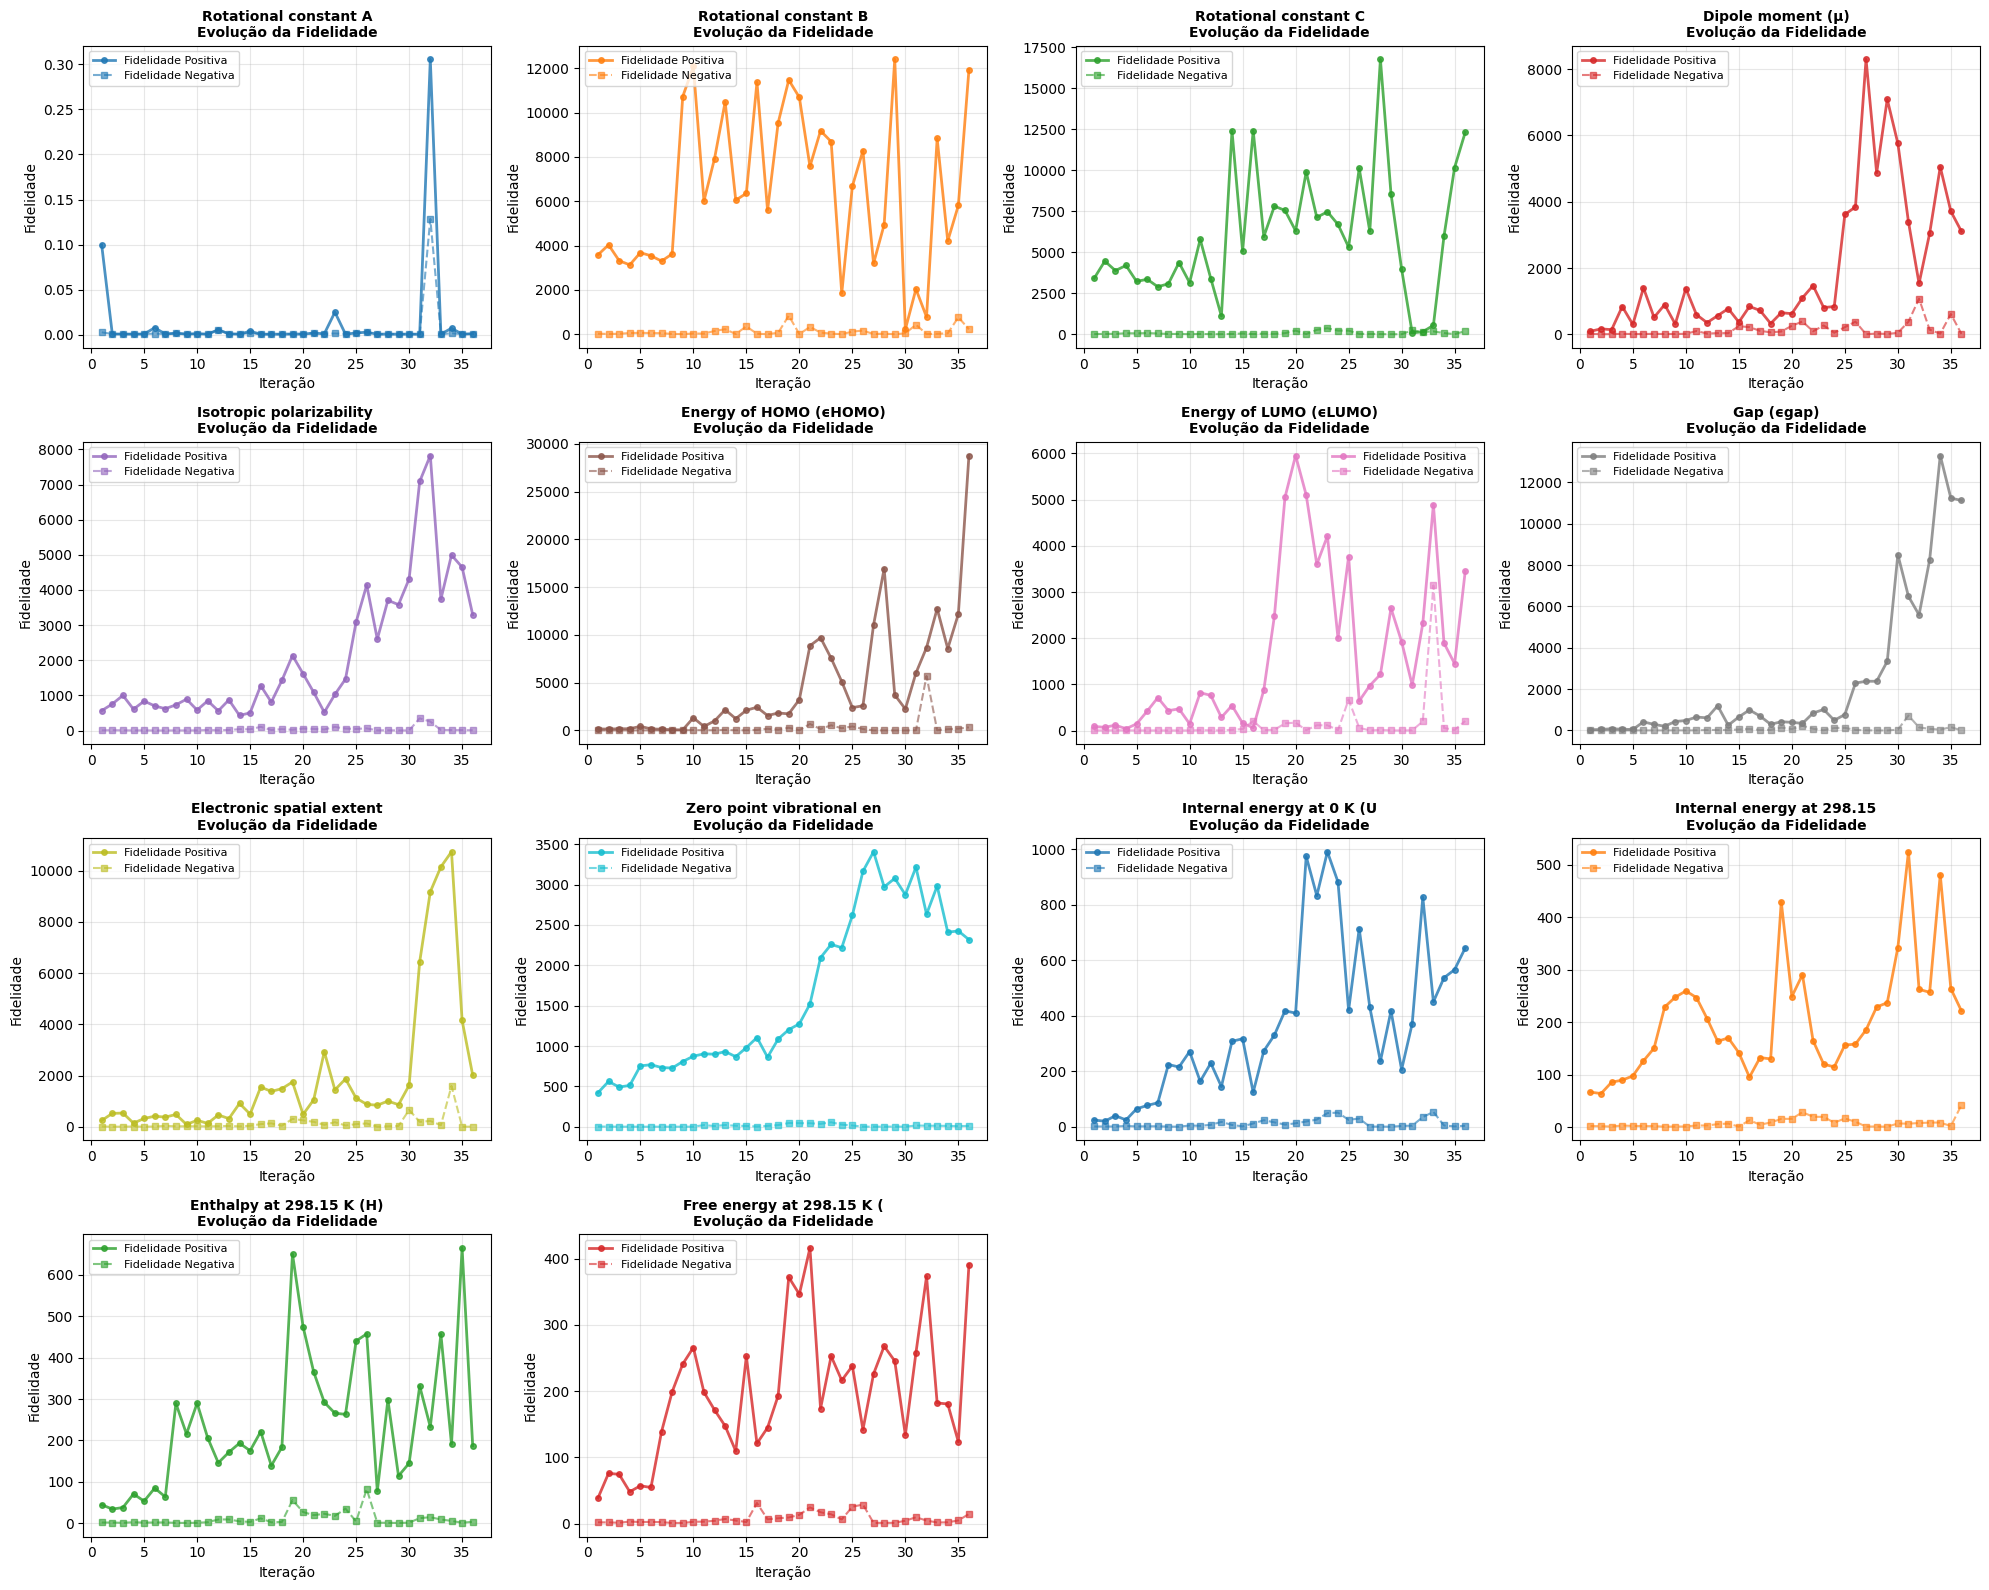

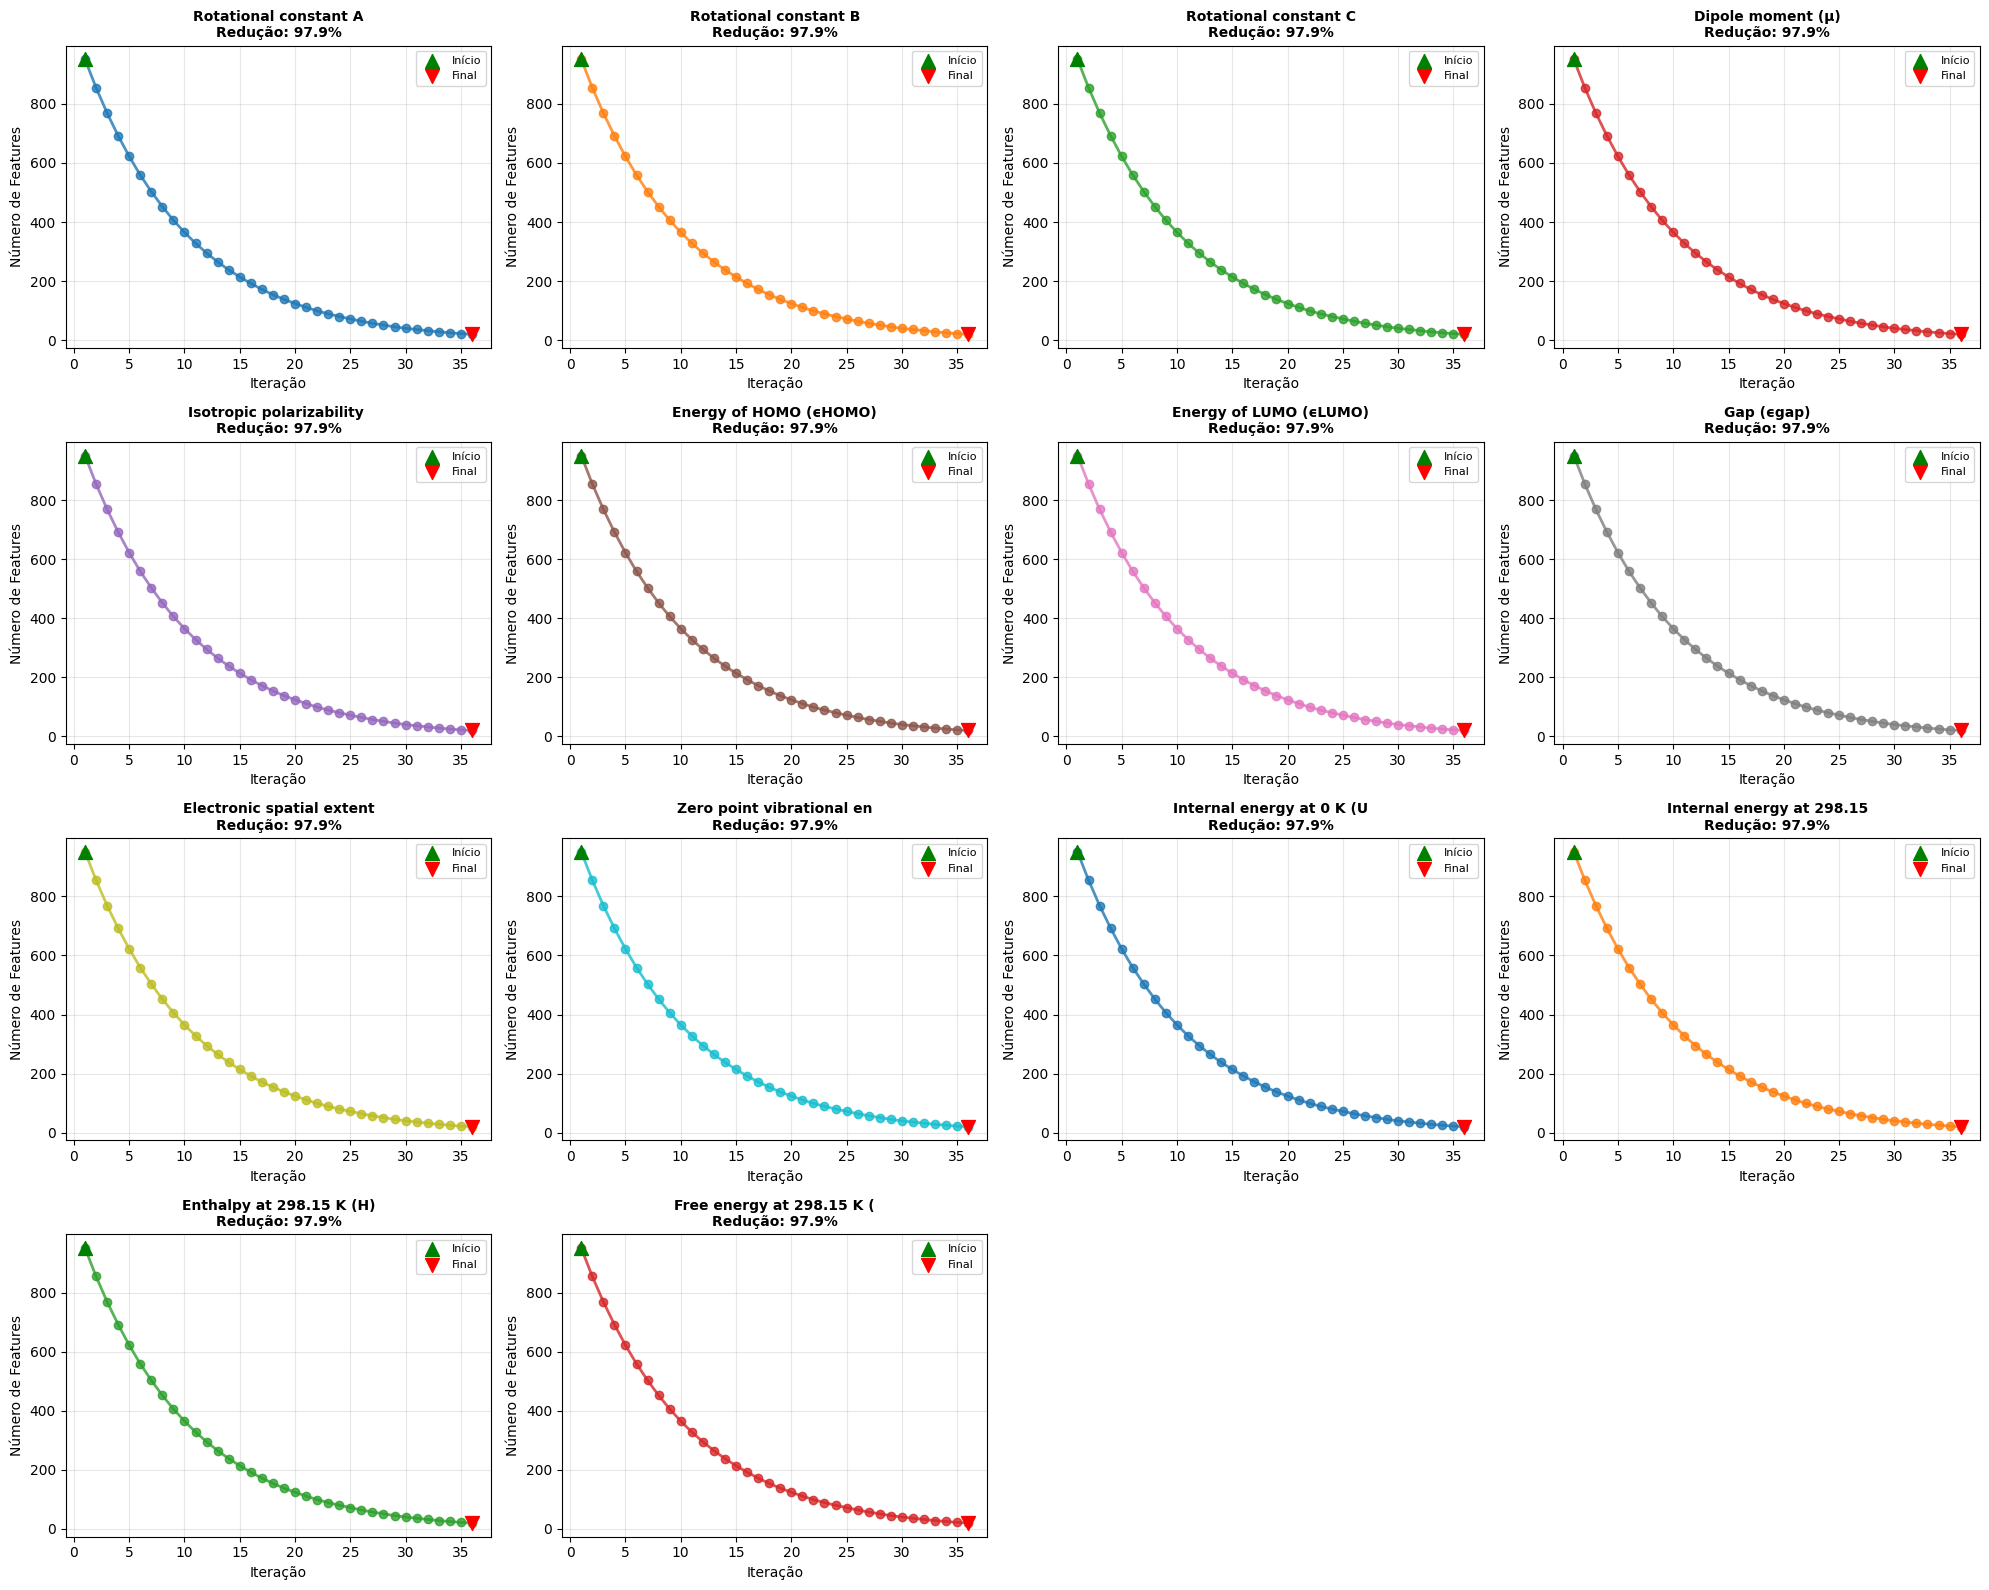

/tmp/ipykernel_15217/3982894277.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([shap_values], patch_artist=True,
/tmp/ipykernel_15217/3982894277.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([shap_values], patch_artist=True,
/tmp/ipykernel_15217/3982894277.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([shap_values], patch_artist=True,
/tmp/ipykernel_15217/3982894277.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in

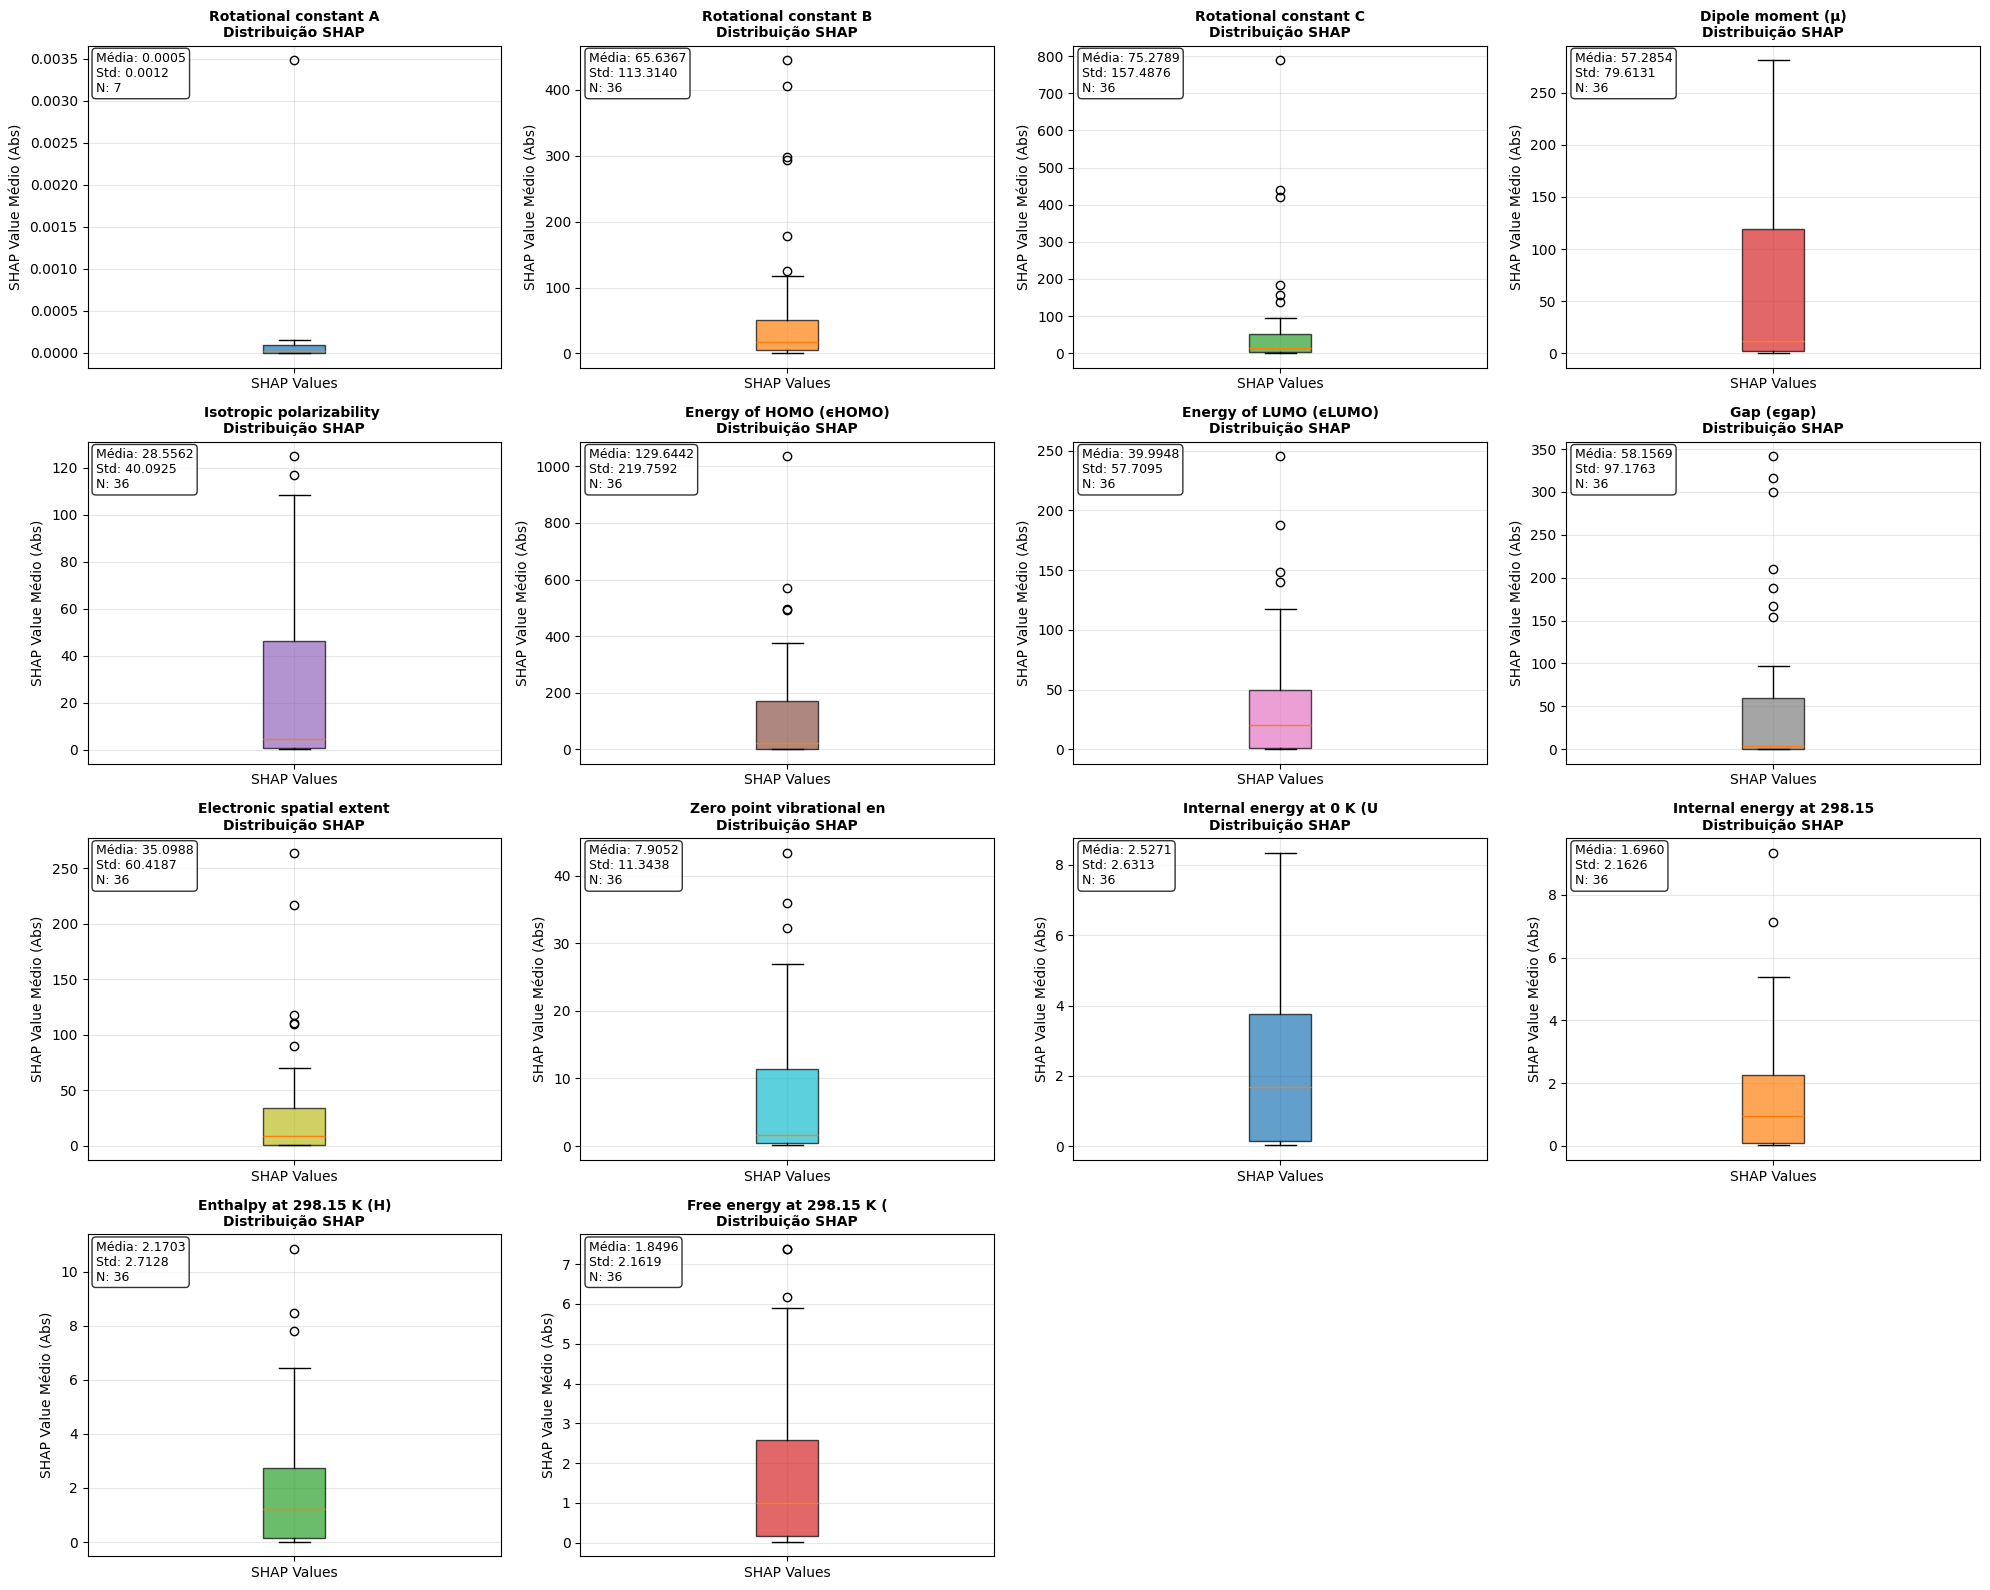

In [43]:
# 2. ANÁLISE INDIVIDUAL DOS DADOS DE EXPLICAÇÃO PARA CADA PROPRIEDADE
import ast

# Processar dados SHAP para todas as propriedades
def safe_literal_eval(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) and x != 'None' and pd.notna(x) else []
    except:
        return []

df_explanation['shap_values'] = df_explanation['shap_explanation'].apply(safe_literal_eval)
df_explanation['mean_shap_abs'] = df_explanation['shap_values'].apply(
    lambda x: np.mean(np.abs(x)) if len(x) > 0 else 0
)

# Filtrar apenas dados válidos com SHAP values
df_shap_valid = df_explanation[df_explanation['mean_shap_abs'] > 0]

properties = df_explanation['property'].unique()
n_props = len(properties)

# Calcular layout de subplots (aproximadamente quadrado)
n_cols = int(np.ceil(np.sqrt(n_props)))
n_rows = int(np.ceil(n_props / n_cols))

# Gráfico 1: Evolução da fidelidade por propriedade (individual)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_props > 1 else [axes]

for i, prop in enumerate(properties):
    prop_data = df_explanation[df_explanation['property'] == prop]
    valid_pos = prop_data.dropna(subset=['positive_fidelity'])
    valid_neg = prop_data.dropna(subset=['negative_fidelity'])
    
    if len(valid_pos) > 0:
        color = colors[i % len(colors)]
        axes[i].plot(valid_pos['iteration'], valid_pos['positive_fidelity'], 
                    'o-', label='Fidelidade Positiva', linewidth=2, markersize=4, 
                    color=color, alpha=0.8)
        axes[i].plot(valid_neg['iteration'], valid_neg['negative_fidelity'], 
                    's--', label='Fidelidade Negativa', color=color, alpha=0.6, markersize=4)
        
        axes[i].set_xlabel('Iteração')
        axes[i].set_ylabel('Fidelidade')
        axes[i].set_title(f'{prop.split(":")[0][:25]}\nEvolução da Fidelidade', fontsize=10, fontweight='bold')
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, 'Sem dados\nde fidelidade', 
                    transform=axes[i].transAxes, ha='center', va='center',
                    fontsize=12, color='gray')
        axes[i].set_title(f'{prop.split(":")[0][:25]}', fontsize=10)

# Esconder subplots não utilizados
for j in range(len(properties), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Gráfico 2: Redução de Features por propriedade (individual)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_props > 1 else [axes]

for i, prop in enumerate(properties):
    prop_data = df_explanation[df_explanation['property'] == prop]
    color = colors[i % len(colors)]
    
    axes[i].plot(prop_data['iteration'], prop_data['n_features'], 
                'o-', linewidth=2, markersize=6, color=color, alpha=0.8)
    
    # Destacar início e fim
    initial_features = prop_data['n_features'].iloc[0]
    final_features = prop_data['n_features'].iloc[-1]
    reduction_pct = ((initial_features - final_features) / initial_features) * 100
    
    axes[i].scatter(prop_data['iteration'].iloc[0], initial_features, 
                   s=100, color='green', marker='^', zorder=5, label='Início')
    axes[i].scatter(prop_data['iteration'].iloc[-1], final_features, 
                   s=100, color='red', marker='v', zorder=5, label='Final')
    
    axes[i].set_xlabel('Iteração')
    axes[i].set_ylabel('Número de Features')
    axes[i].set_title(f'{prop.split(":")[0][:25]}\nRedução: {reduction_pct:.1f}%', 
                     fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Esconder subplots não utilizados
for j in range(len(properties), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Gráfico 3: SHAP Values por propriedade (individual)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_props > 1 else [axes]

for i, prop in enumerate(properties):
    prop_data = df_shap_valid[df_shap_valid['property'] == prop]
    
    if len(prop_data) > 0:
        color = colors[i % len(colors)]
        
        # Boxplot dos SHAP values para esta propriedade
        shap_values = prop_data['mean_shap_abs'].values
        bp = axes[i].boxplot([shap_values], patch_artist=True, 
                           labels=['SHAP Values'])
        bp['boxes'][0].set_facecolor(color)
        bp['boxes'][0].set_alpha(0.7)
        
        # Adicionar estatísticas
        axes[i].text(0.02, 0.98, 
                    f'Média: {np.mean(shap_values):.4f}\nStd: {np.std(shap_values):.4f}\nN: {len(shap_values)}', 
                    transform=axes[i].transAxes, fontsize=9,
                    verticalalignment='top', horizontalalignment='left',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    else:
        axes[i].text(0.5, 0.5, 'Sem dados\nSHAP válidos', 
                    transform=axes[i].transAxes, ha='center', va='center',
                    fontsize=12, color='gray')
    
    axes[i].set_ylabel('SHAP Value Médio (Abs)')
    axes[i].set_title(f'{prop.split(":")[0][:25]}\nDistribuição SHAP', fontsize=10, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

# Esconder subplots não utilizados
for j in range(len(properties), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

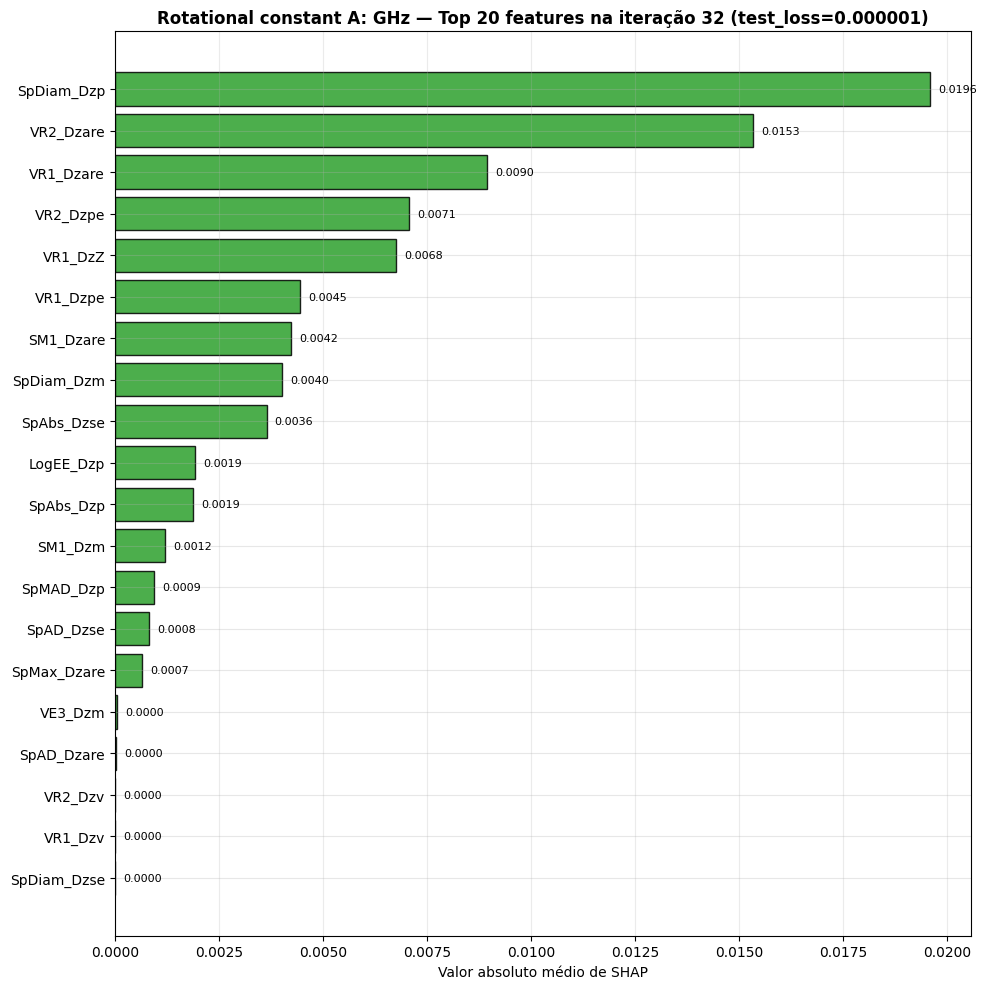

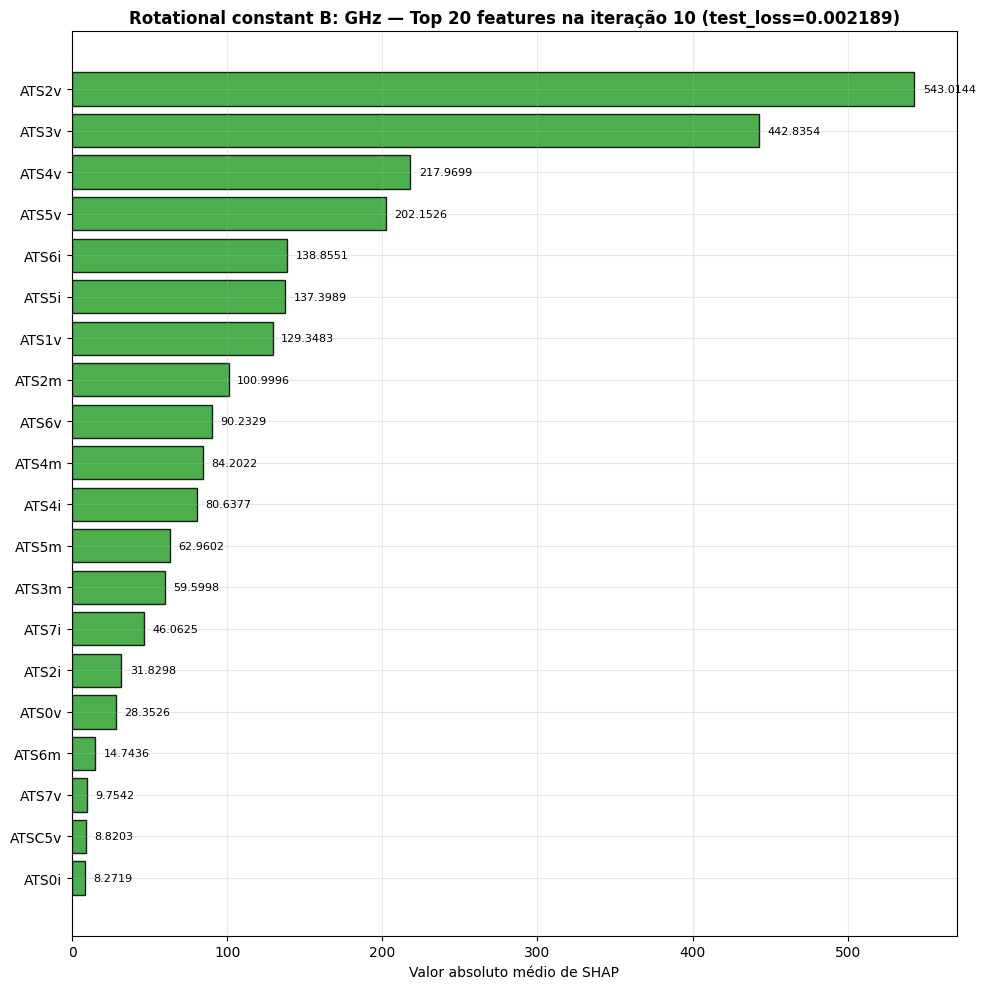

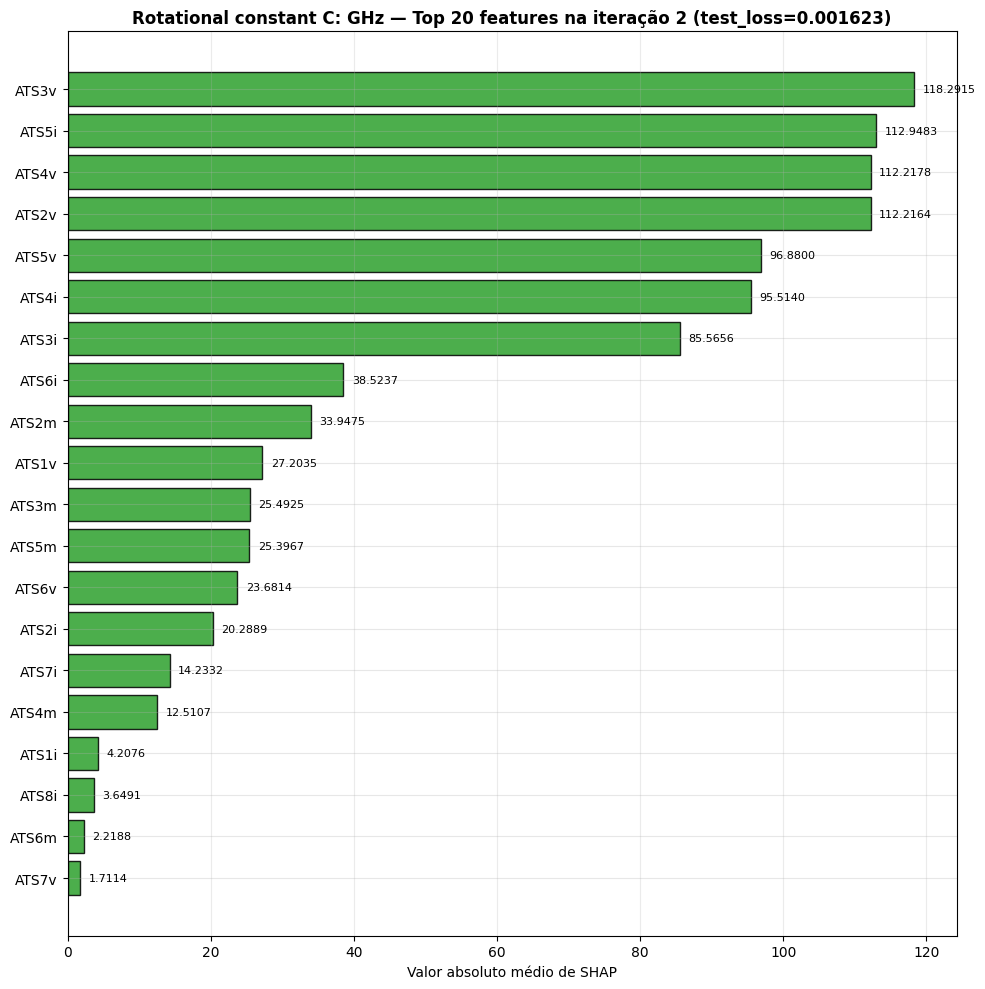

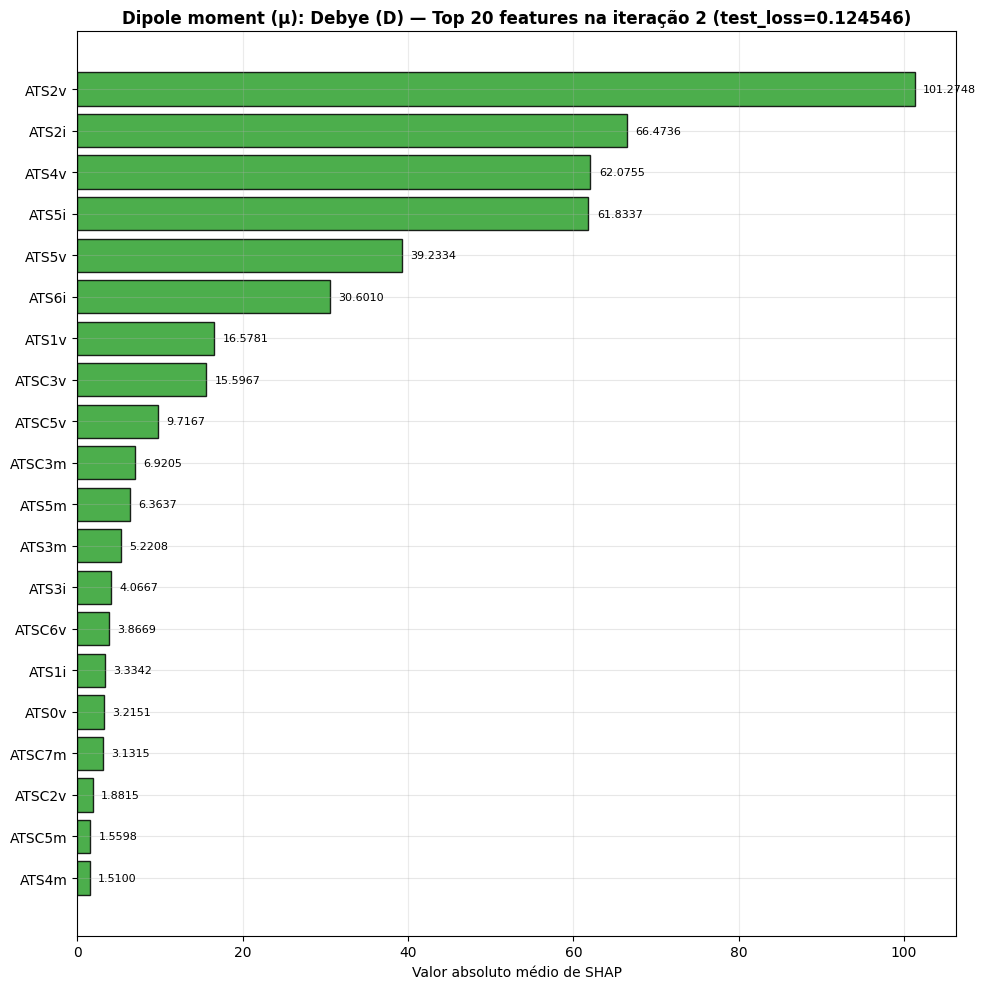

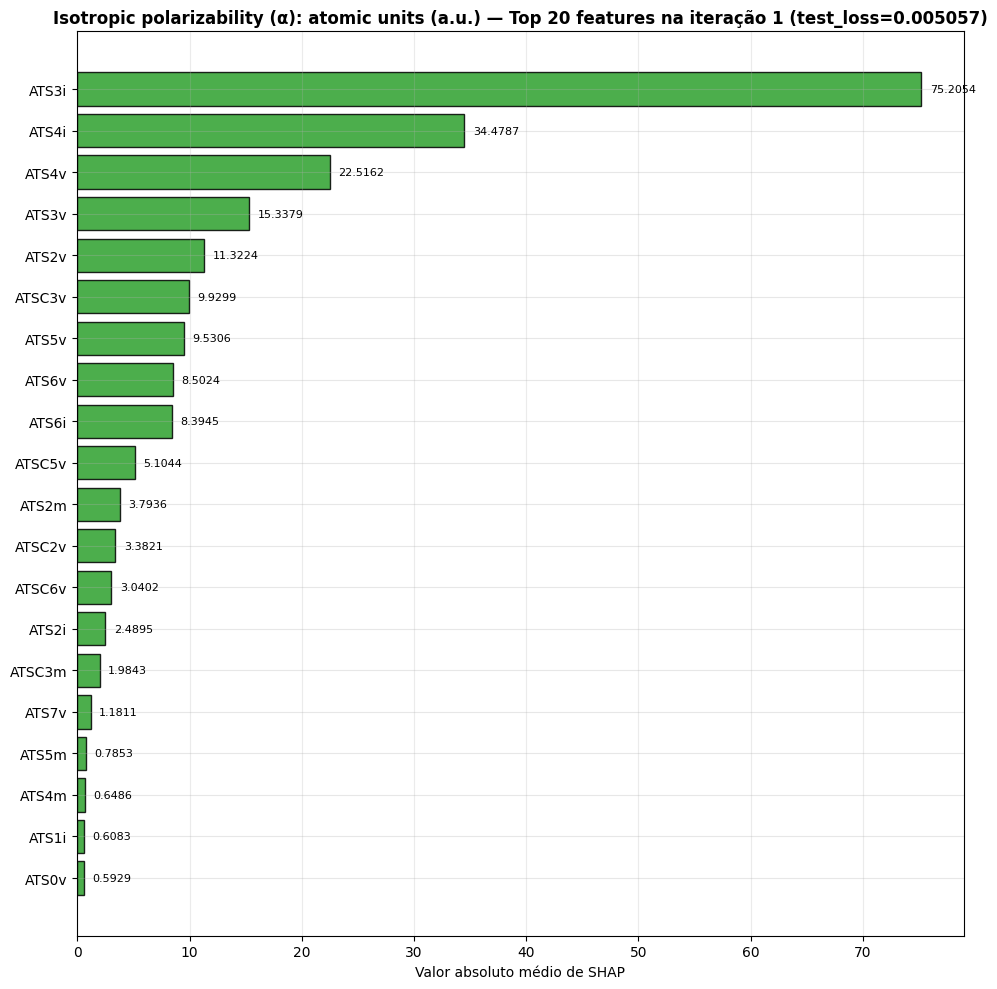

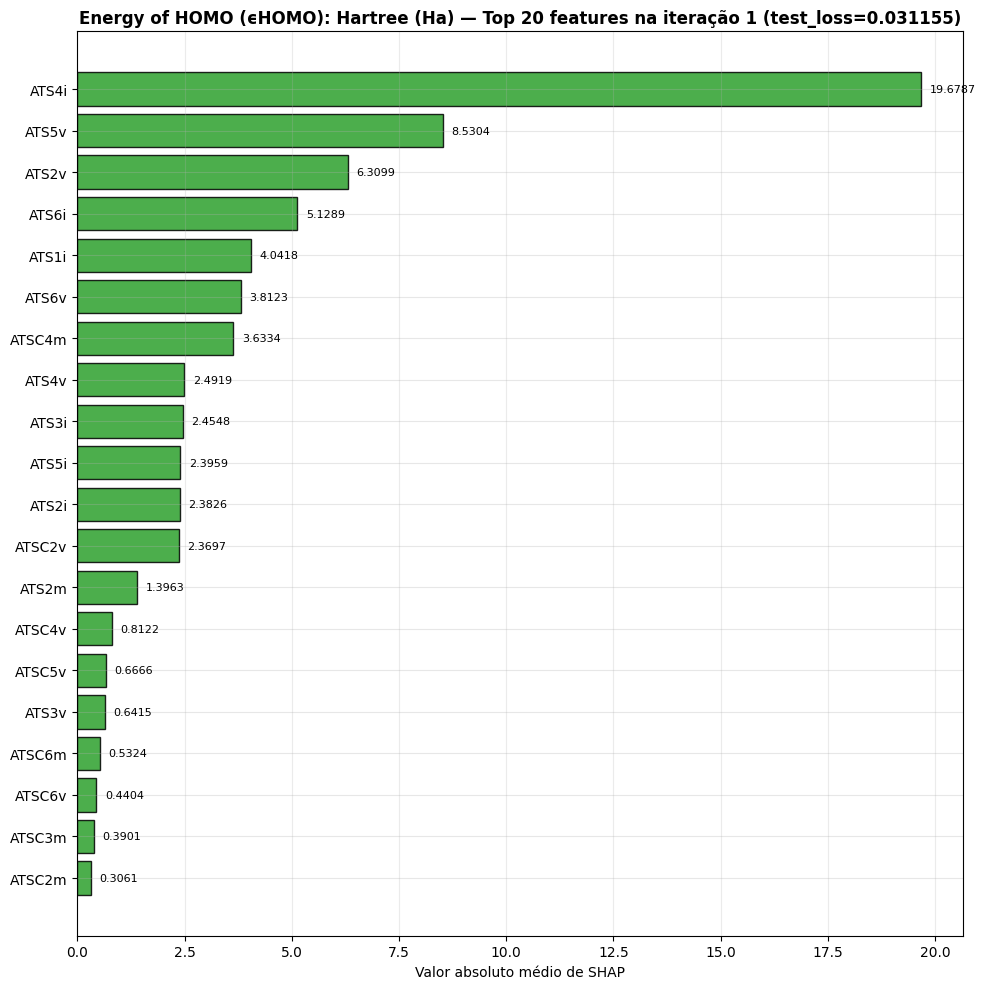

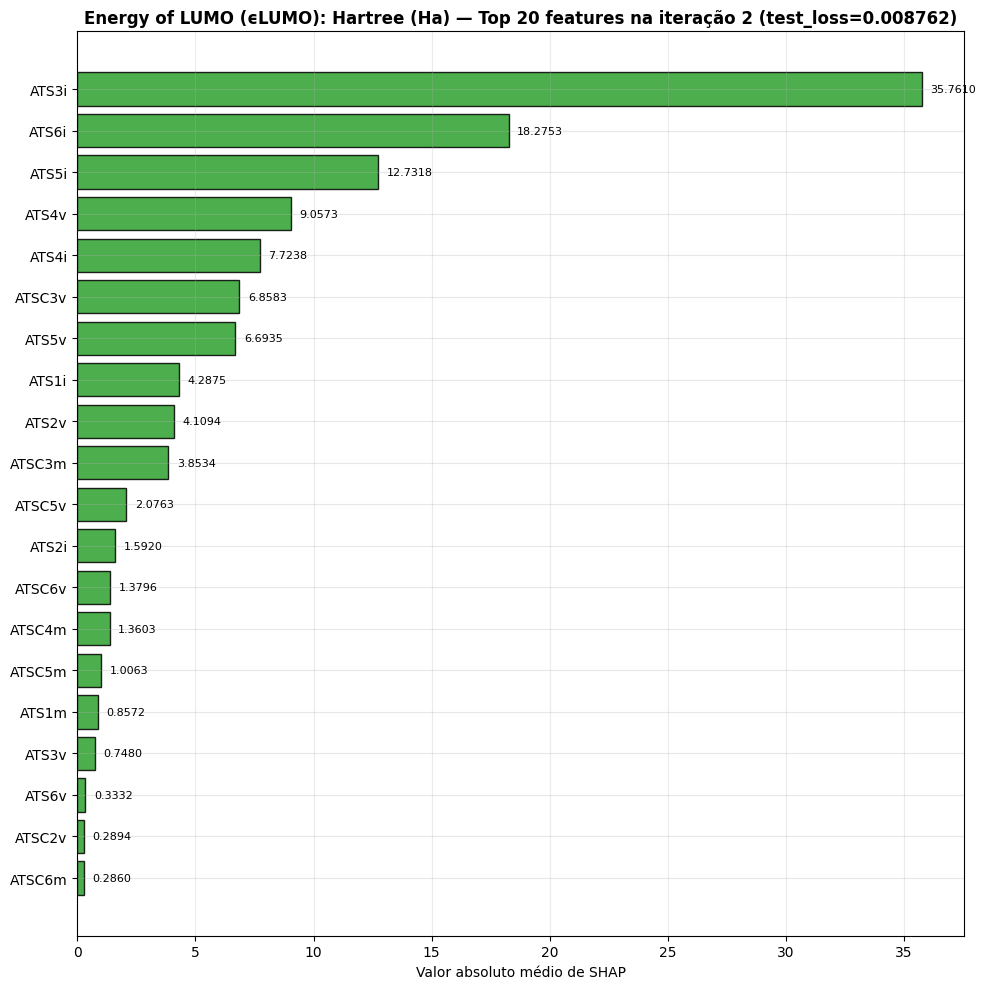

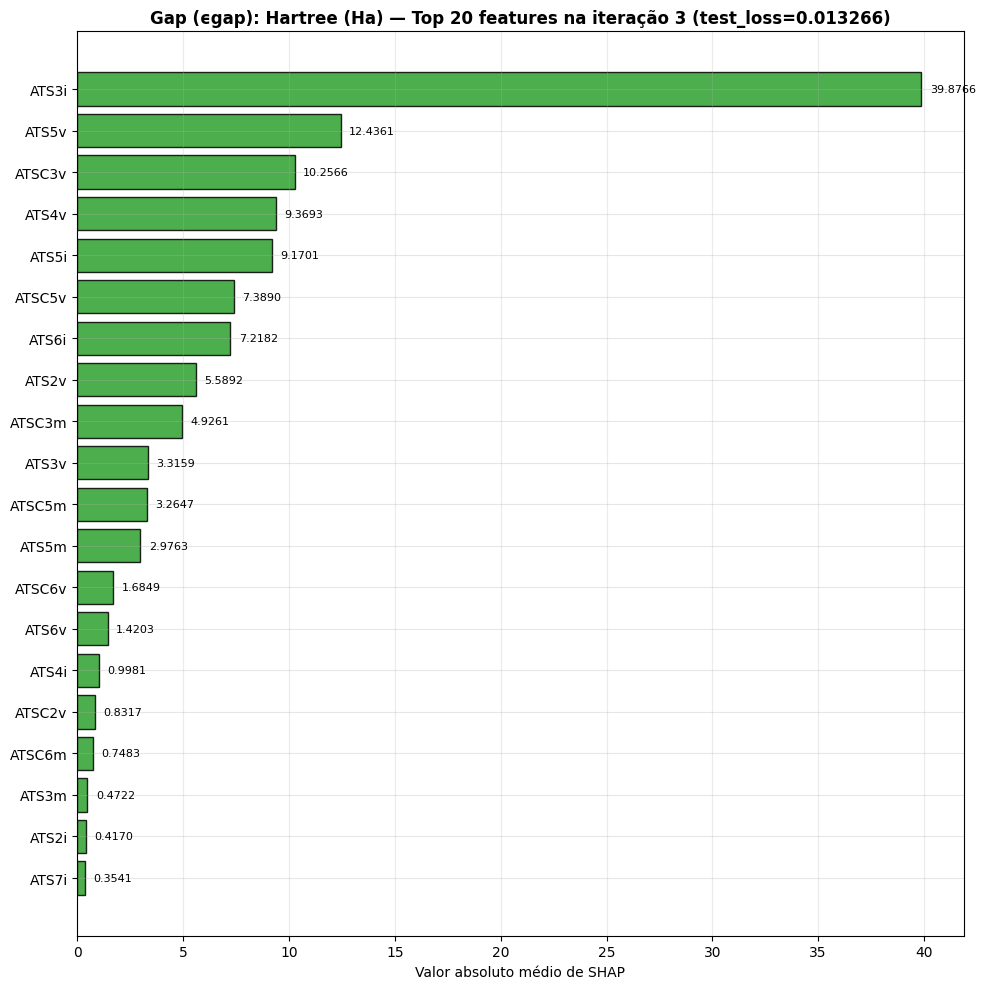

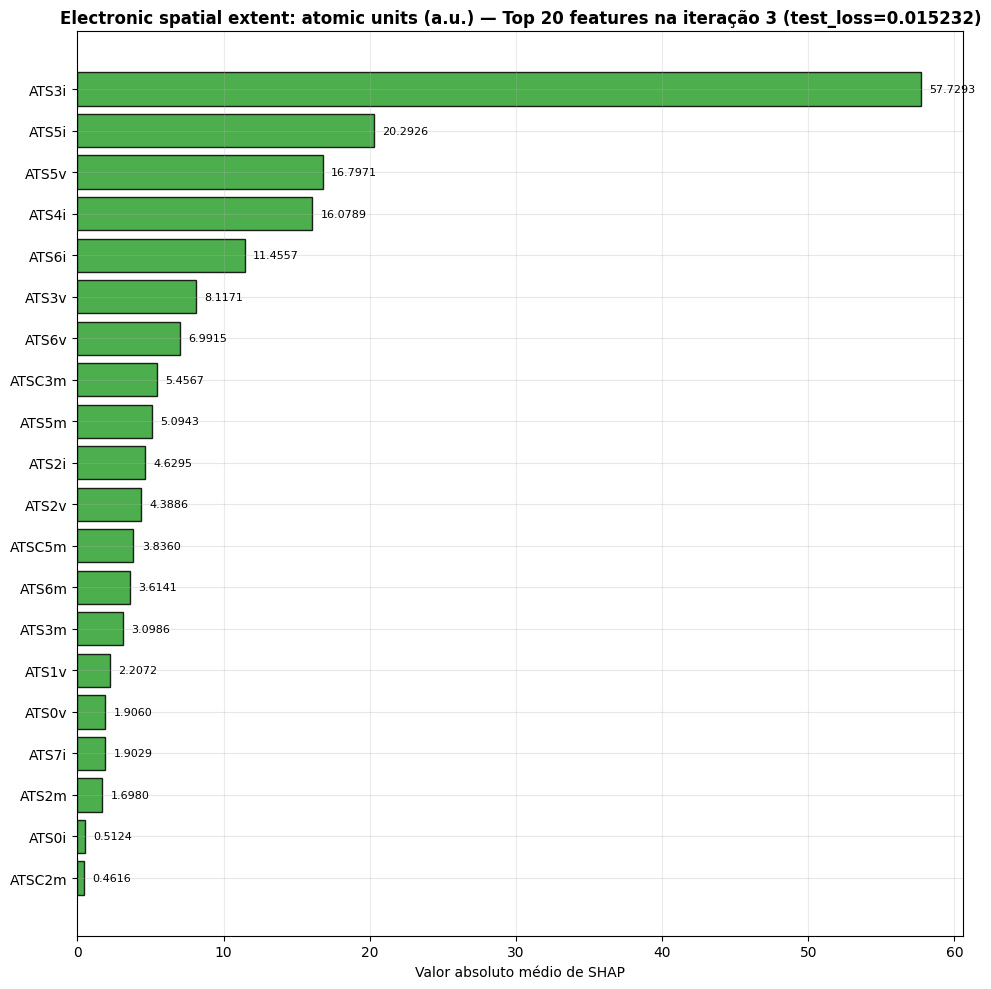

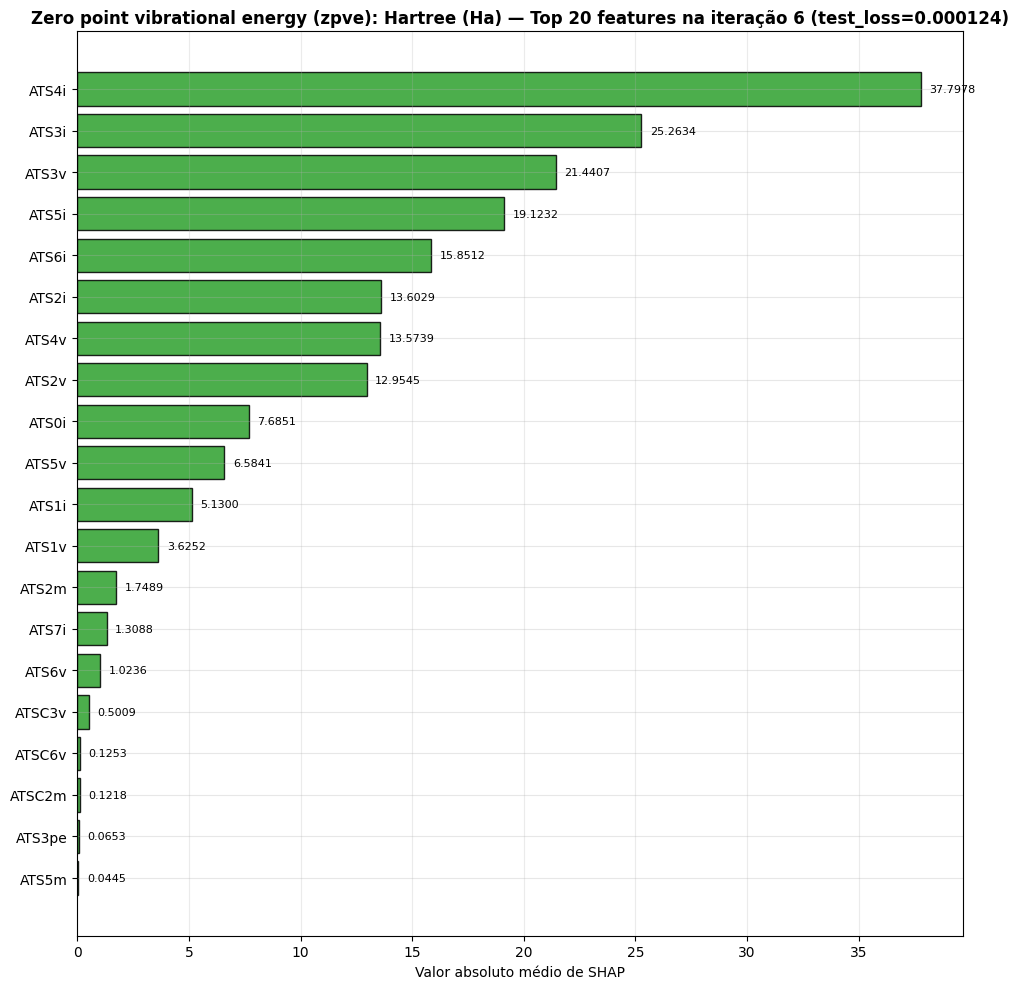

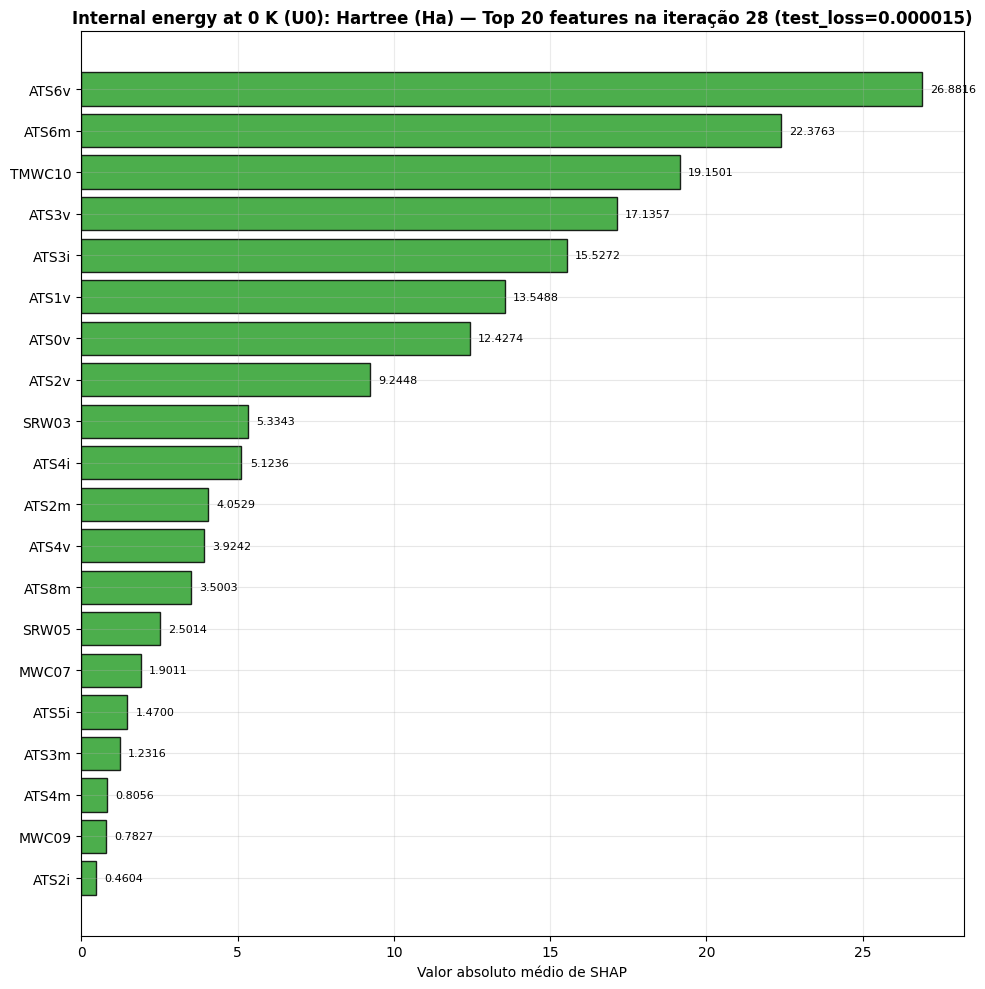

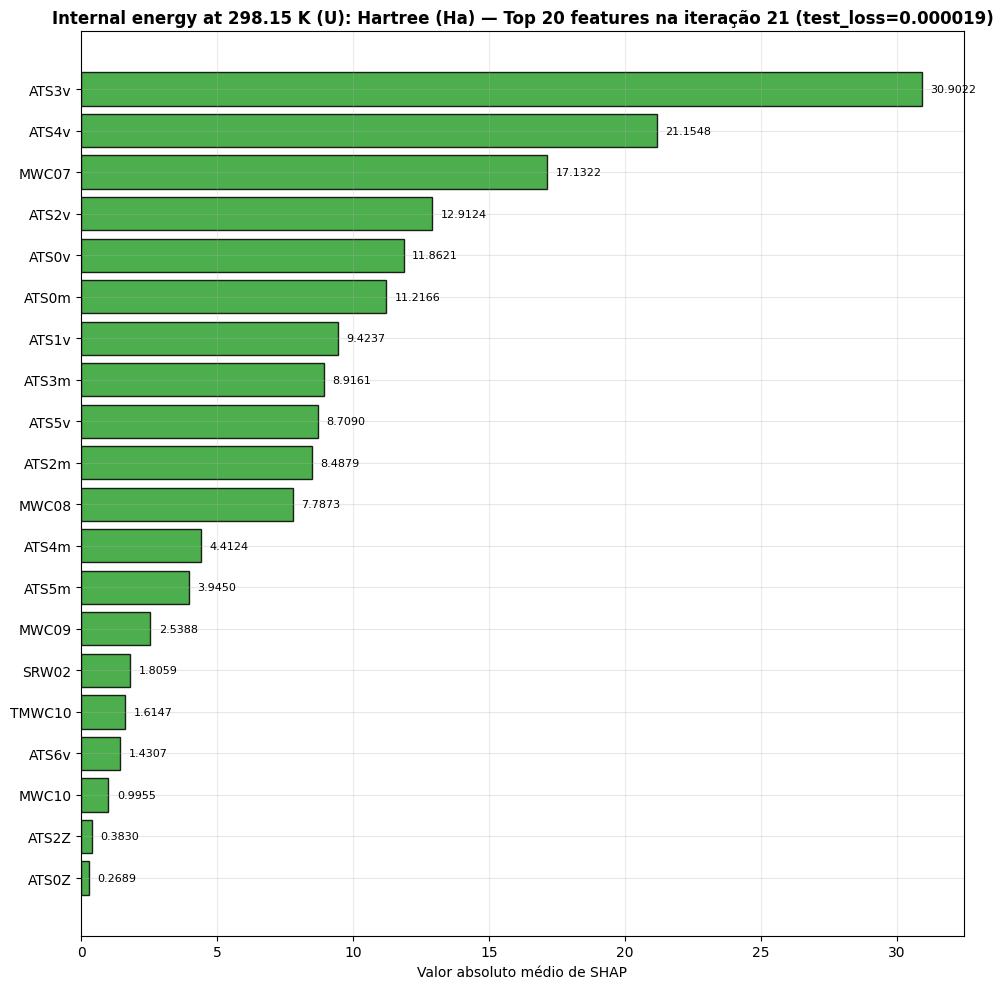

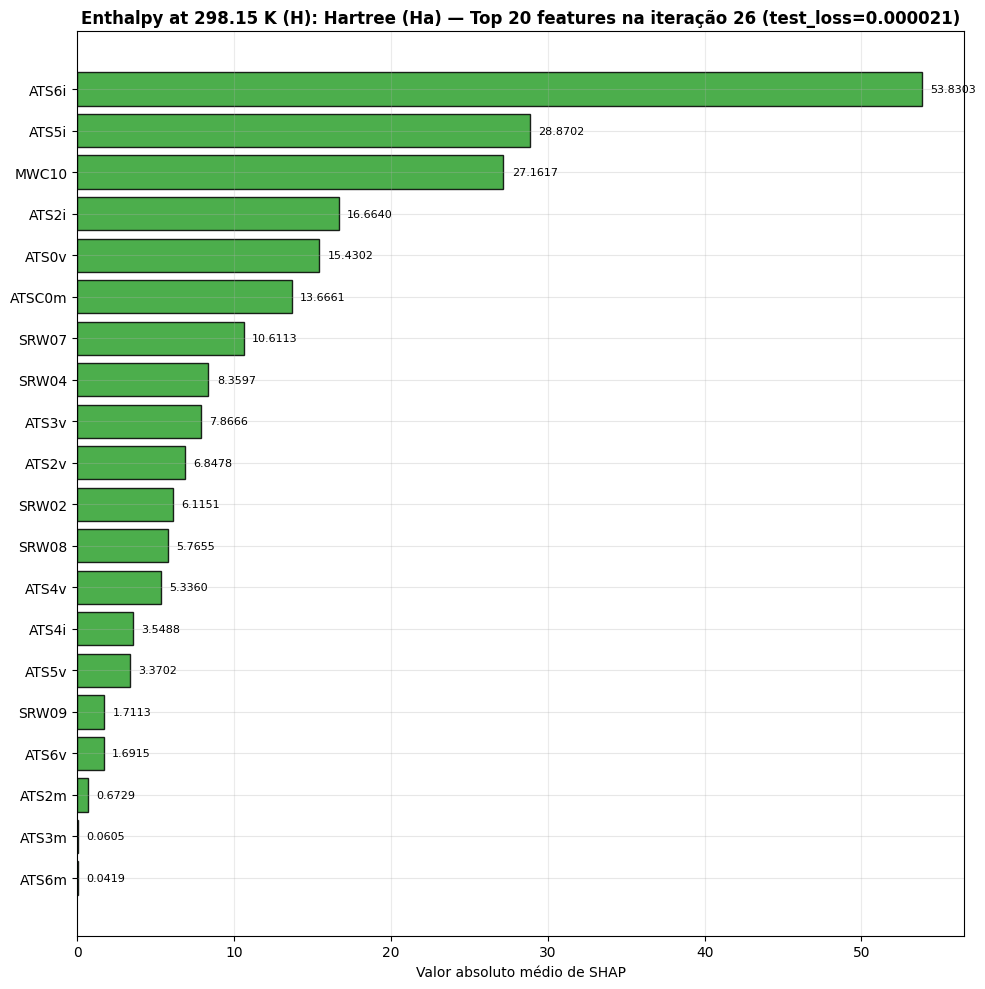

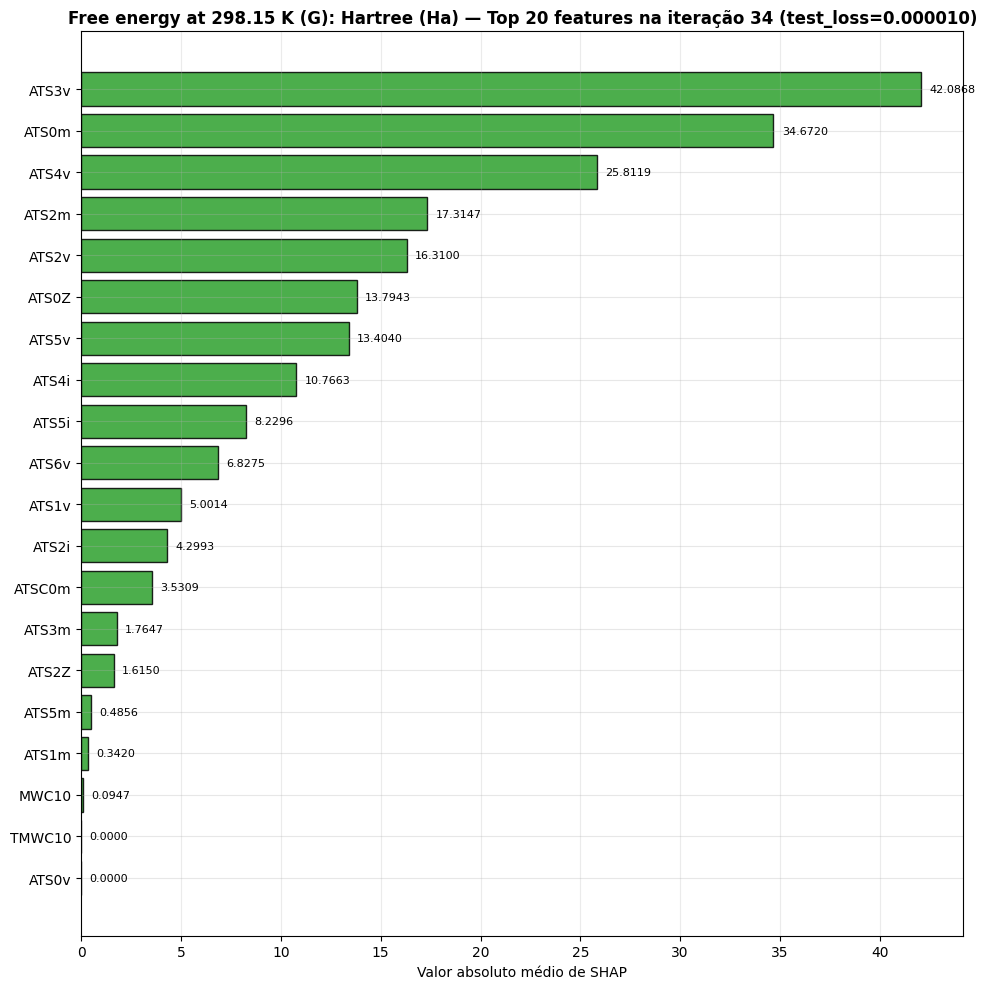

In [44]:
# 2.1. GRÁFICOS DE EXPLICAÇÃO (Top-20 features na iteração de menor test_loss)
# Para cada propriedade, seleciona a iteração com menor test_loss em `df_explanation` e plota um barplot
# com os nomes das features e seus valores absolutos de SHAP (ou média se for array por amostra).
# Mostra apenas as 20 features mais influentes por propriedade.

# Ajuste: mostrar no máximo top_n features
,
def extract_shap_feature_pairs(row):
    # Usa safe_literal_eval já definido anteriormente no notebook
    feats = safe_literal_eval(row.get('features_selected', '[]'))
    shap = safe_literal_eval(row.get('shap_explanation', '[]'))
    # Se shap for 2D (por amostra x features), faz média das abs por feature
    try:
        arr = np.array(shap)
        if arr.ndim == 2:
            # média dos absolutos ao longo do axis 0 (amostras) -> por feature
            vals = np.mean(np.abs(arr), axis=0).tolist()
        else:
            vals = np.abs(arr).tolist()
    except Exception:
        vals = []
    # Se não houver nomes de features, tenta usar original_indices como rótulos
    if (not feats or len(feats) == 0) and 'original_indices' in row and pd.notna(row['original_indices']):
        try:
            idxs = safe_literal_eval(row['original_indices'])
            feats = [str(i) for i in idxs]
        except Exception:
            feats = [str(i) for i in range(len(vals))]
    # Ajustar tamanhos (se necessário)
    if len(vals) != len(feats):
        # Se shapes não baterem, cria rótulos genéricos numéricos e trunca/expande conforme necessário
        n = min(len(vals), len(feats)) if (len(vals)>0 and len(feats)>0) else max(len(vals), len(feats))
        feats = feats[:n] if len(feats) >= n else [f'feat_{i}' for i in range(n)]
        vals = vals[:n] if len(vals) >= n else ([0.0]*n)
    return list(zip(feats, vals))

# Plot por propriedade: barra horizontal ordenada por importância (mostrar apenas top_n)
top_n = 20
properties = df_explanation['property'].unique()
for prop in properties:
    prop_df = df_explanation[df_explanation['property'] == prop]
    if prop_df.empty:
        continue
    # Encontrar a linha com menor test_loss (usar coluna test_loss em df_explanation)
    if 'test_loss' in prop_df.columns and prop_df['test_loss'].notna().any():
        idx_min = prop_df['test_loss'].idxmin()
        row = prop_df.loc[idx_min]
    else:
        # fallback: usar a primeira linha
        row = prop_df.iloc[0]
    pairs = extract_shap_feature_pairs(row)
    if not pairs or len(pairs) == 0:
        print(f"Sem explicações válidas para {prop} na iteração {row.get('iteration', '?')}")
        continue
    # criar dataframe para ordenar e plotar
    df_pairs = pd.DataFrame(pairs, columns=['feature', 'shap_abs'])
    # selecionar top_n pelo valor absoluto (desc), depois ordenar asc para barh (mais pequeno em cima)
    df_pairs = df_pairs.sort_values('shap_abs', ascending=False).head(top_n).sort_values('shap_abs', ascending=True)
    # tamanho da figura dinâmico conforme número de features (limitado)
    n_feats = len(df_pairs)
    h = min(0.4 * n_feats + 2, 14)  # ajustar para caber 20 barras confortavelmente
    plt.figure(figsize=(10, h))
    bars = plt.barh(df_pairs['feature'], df_pairs['shap_abs'], color='#2ca02c', alpha=0.85, edgecolor='black')
    plt.xlabel('Valor absoluto médio de SHAP')
    plt.title(f"{prop} — Top {n_feats} features na iteração {int(row.get('iteration',0))} (test_loss={row.get('test_loss', np.nan):.6f})", fontsize=12, fontweight='bold')
    plt.grid(axis='x', alpha=0.25)
    # adicionar rótulos numéricos ao lado de cada barra
    max_val = df_pairs['shap_abs'].max() if n_feats>0 else 0
    for bar in bars:
        w = bar.get_width()
        plt.text(w + max(max_val*0.01, 1e-6), bar.get_y() + bar.get_height()/2, f"{w:.4f}", va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

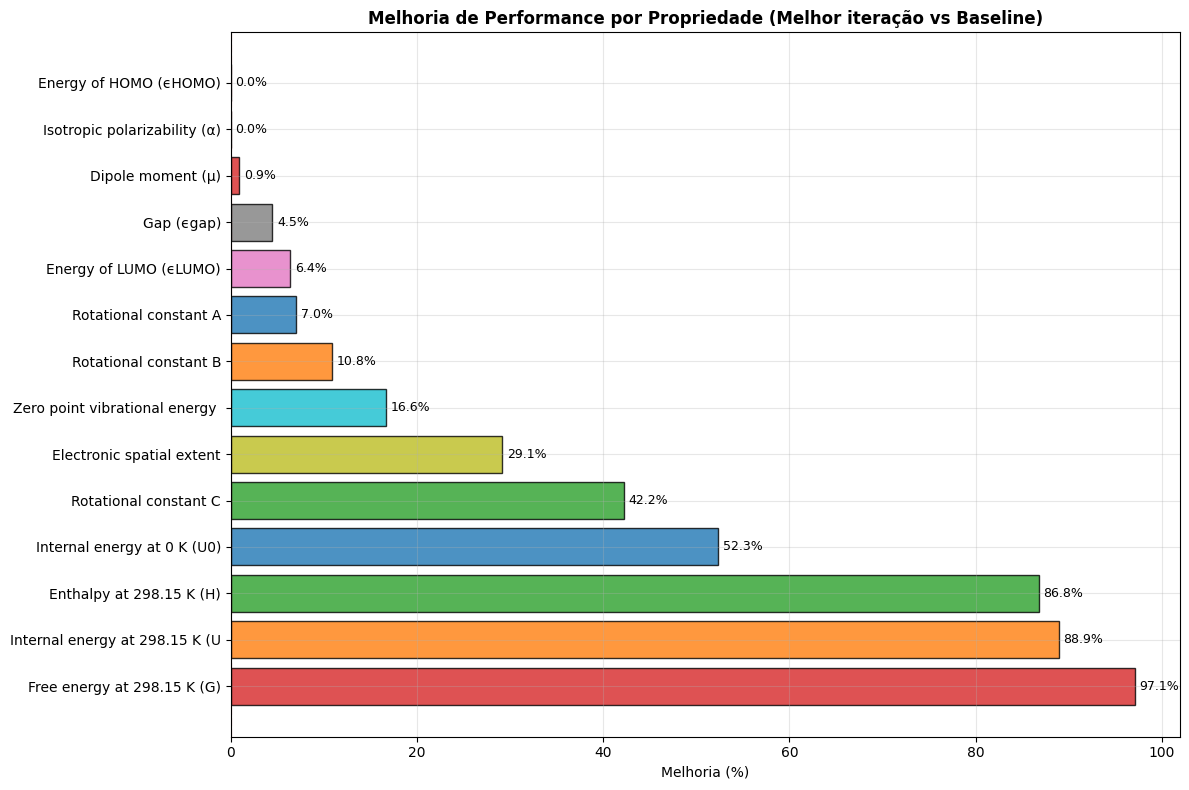

In [46]:
# 4. COMPARAÇÃO DE EFICIÊNCIA ENTRE PROPRIEDADES
# Apenas um plot: Melhoria relativa por propriedade (melhor iteração vs baseline)
fig, ax = plt.subplots(figsize=(12, 8))

# Calcular melhorias por propriedade
improvements = []
property_names = []
baseline_losses = []
best_losses = []

for prop in df_degradation['property'].unique():
    prop_data = df_degradation[df_degradation['property'] == prop]
    baseline = prop_data['test_loss'].iloc[0]
    best = prop_data['test_loss'].min()
    improvement = ((baseline - best) / baseline) * 100
    
    improvements.append(improvement)
    property_names.append(prop.split(':')[0][:30])
    baseline_losses.append(baseline)
    best_losses.append(best)

# Ordenar por melhoria para melhor visualização (opcional)
order = np.argsort(improvements)[::-1]  # desc
property_names_ordered = [property_names[i] for i in order]
improvements_ordered = [improvements[i] for i in order]
colors_ordered = [colors[i % len(colors)] for i in order]

# Barras horizontais para melhoria
bars = ax.barh(range(len(improvements_ordered)), improvements_ordered, 
               color=colors_ordered, alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(property_names_ordered)))
ax.set_yticklabels(property_names_ordered, fontsize=10)
ax.set_xlabel('Melhoria (%)')
ax.set_title('Melhoria de Performance por Propriedade (Melhor iteração vs Baseline)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.8)

# Adicionar valores nas barras
for idx, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.5 if width >= 0 else width - 0.5, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', ha='left' if width >= 0 else 'right', va='center', fontsize=9)

plt.tight_layout()
plt.show()